# Neural Trajectory Divergence Analysis

This notebook implements analysis for detecting when STOP trial neural trajectories diverge from GO baseline.

Here we look at the data and explor the structure of GO trials.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.special import gammaln
import sys

# Add parent directory to path
sys.path.insert(0, str(Path.cwd().parent))

import importlib
import session_class
import cell_analysis
import multi_session_pca
importlib.reload(session_class)
importlib.reload(cell_analysis)
importlib.reload(multi_session_pca)

from session_class import Session
from cell_analysis import Cell
from multi_session_pca import MultiSessionPCA

import holoviews as hv
from holoviews import opts
from bokeh.io import output_notebook
output_notebook()
hv.extension('bokeh')

print("Imports loaded successfully!")

Loading BokehJS ...

Imports loaded successfully!


# Import MultiSessionPCA
sys.path.insert(0, str(Path.cwd().parent.parent))
from population_analysis.multi_session_pca import MultiSessionPCA

# Load data and validate sessions
pca_analyzer = MultiSessionPCA()
pca_analyzer.load_data(pickle_file)
pca_analyzer.get_session_statistics()
pca_analyzer.validate_all_sessions(verbose=False)

# Display validation results sorted by number of cells
validation_summary = pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].copy()
validation_summary = validation_summary.sort_values('n_cells', ascending=False)

print("\nValid Sessions (sorted by neuron count):")
print("=" * 60)
for idx, row in validation_summary.iterrows():
    print(f"{row['session_id']}: {row['n_cells']} cells")

# Find best session
best_session = validation_summary.iloc[0]
print(f"\n{'='*60}")
print(f"BEST SESSION: {best_session['session_id']} with {best_session['n_cells']} cells")
print(f"{'='*60}")

## 1. Load Data, instantiate session and populate variables 

### 1.A Variables and Parameters

In [2]:
base_path = Path.cwd().parents[1] / 'data' / 'unified_cell_trial_data'
pickle_file = base_path / 'msn_fiona_cell_trial_data.pkl'

session_id = 'fi211025a'  

dir_map = {0: 'Right', 180: 'Left'}

SSD_NUM = 2
EPOK = [-300, 300]
BIN_SIZE = 50  # Bin width in ms
BIN_STEP = 10   # Bin step size in ms (sliding windows)
FR_MIN = 1.0    # Hz
DIRECTION = 0  # Left (has more STOP trials)

### 1.B get instances

In [3]:
# Load MSN cell database
cell_df = pd.read_pickle(pickle_file)

# Select session 
session_data = cell_df[cell_df['trial_session'] == session_id]

# Create Session object
session = Session(session_data, verbose=True)

# Drop cells with missing trial type or direction data
session.drop_cells_with_missing_trial_type_or_dir_data()

print(f"\nSession {session_id} loaded successfully!")
print(f"Number of cells after filtering: {session.n_cells}")
print(f"Total cell-trial combinations: {len(session.data)}")

Session fi211025a initialized:
  - Number of cells: 155
  - Total trials: 1950
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]

Session fi211025a loaded successfully!
Number of cells after filtering: 155
Total cell-trial combinations: 107982


### 1.C Clean data
Remove GO trials with reaction time greater than mean SSD length (pluse maybe a buffer)

In [4]:
session.data.columns

Index(['cell_ID', 'cell_type', 'maestro_ID', 'problem', 'grade', 'filename',
       'trial_name', 'reaction_time', 'go_cue', 'stop_cue', 'trial_failed',
       'ssd_len', 'ssd_number', 'type', 'first_relevant_saccade',
       'segs_durations', 'segs_times', 'trial_length', 'screen_rotation',
       'saccades', 'blinks', 'dir', 'neural_data', 'session', 'plexon_session',
       'trial_number', 'trial_session'],
      dtype='object')

In [5]:
def is_go_trial_with_valid_saccade(row, mean_ssd):
    if (row['type'] != 'GO'):
        return True
    if np.isnan(row['first_relevant_saccade']).any():
        return False
    saccade_onset = row['first_relevant_saccade'][0]
    return (saccade_onset - row['go_cue']) > mean_ssd

oring_data = session.data.copy()
print(oring_data.shape)

stop_trials = session.data[
    (session.data['type'] == 'STOP') & 
    (session.data['trial_failed'] == False) & 
    (session.data['dir'] == DIRECTION) &
    (session.data['ssd_number'] == SSD_NUM)
]
mean_ssd = stop_trials['ssd_len'].mean()
print(f"Mean SSD length for successful STOP SSD{SSD_NUM} trials: {mean_ssd:.2f} ms")

session.data[
    ~session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
]["trial_number"].value_counts().shape

# Filter GO trials
# session.data = session.data[
#     session.data.apply(lambda row: is_go_trial_with_valid_saccade(row, mean_ssd), axis=1)
# ]

# print(f"Number of removed trials after GO trial filtering: {oring_data.shape[0] - session.data.shape[0]}")

(107982, 27)
Mean SSD length for successful STOP SSD2 trials: 108.00 ms


(76,)

## 2. Check Trial Counts

Verify we have enough GO and STOP SSD2 trials for each direction.

In [6]:
# Count successful trials for GO and STOP SSD2 by direction

results = []
for dir in [0, 180]:
    dir_name = dir_map[dir]
    
    # GO trials (successful only) - count unique trial numbers
    go_count = len(session.data[
        (session.data['type'] == 'GO') & 
        (session.data['dir'] == dir) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'GO', 'Trial Count': go_count})
    
    # STOP SSD2 trials (successful only)
    stop_count = len(session.data[
        (session.data['type'] == 'STOP') & 
        (session.data['dir'] == dir) & 
        (session.data['ssd_number'] == SSD_NUM) &
        (session.data['trial_failed'] == False)
    ].drop_duplicates(subset=['trial_number']))
    results.append({'Direction': dir_name, 'Type': 'STOP SSD2', 'Trial Count': stop_count})

results_df = pd.DataFrame(results)
print("\nSuccessful Trial Counts:")
print("=" * 40)
print(results_df.to_string(index=False))


Successful Trial Counts:
Direction      Type  Trial Count
    Right        GO          526
    Right STOP SSD2           40
     Left        GO          520
     Left STOP SSD2           37


In [7]:
session.data['first_relevant_saccade']

1655733    [1400, 1472]
1655734    [1400, 1472]
1655735    [1400, 1472]
1655736    [1400, 1472]
1655737    [1400, 1472]
               ...     
1770131    [1304, 1376]
1770132    [1304, 1376]
1770133    [1304, 1376]
1770134    [1304, 1376]
1770135    [1304, 1376]
Name: first_relevant_saccade, Length: 107982, dtype: object

## 3. Create Trial Number Lists

Extract unique trial numbers for GO and STOP trials by direction.

In [8]:
def filter_trials(session_data, trial_type, direction, ssd_number=None, success_only=True):
    """
    Filter trials based on specified conditions.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data containing trial information
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : float, optional
        SSD level (1.0-4.0) for STOP/CONT trials
    success_only : bool
        If True, only include trials where trial_failed == False
    
    Returns:
    --------
    DataFrame : Filtered session data
    """
    # Base filter
    mask = (session_data['type'] == trial_type) & (session_data['dir'] == direction)
    
    # Add success filter if requested
    if success_only:
        mask &= (session_data['trial_failed'] == False)
    
    # Add SSD filter if specified
    if ssd_number is not None:
        mask &= (session_data['ssd_number'] == ssd_number)
    
    return session_data[mask]


def get_trial_numbers(session_data, trial_type, direction, ssd_number=None, success_only=True):
    """
    Extract unique trial numbers for specified conditions.
    
    Parameters:
    -----------
    session_data : DataFrame
        Session data containing trial information
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : float, optional
        SSD level (1.0-4.0) for STOP/CONT trials
    success_only : bool
        If True, only include trials where trial_failed == False
    
    Returns:
    --------
    list : Sorted list of unique trial numbers
    """
    filtered_data = filter_trials(session_data, trial_type, direction, ssd_number, success_only)
    return sorted(filtered_data['trial_number'].unique())


# Create trial lists for GO and STOP trials
trial_lists = {}

for dir, dir_name in dir_map.items():
    # GO trials
    trial_lists[f'go_{dir_name.lower()}'] = get_trial_numbers(
        session.data, 'GO', dir
    )
    
    # STOP trials with specified SSD
    trial_lists[f'stop_{dir_name.lower()}'] = get_trial_numbers(
        session.data, 'STOP', dir, ssd_number=SSD_NUM
    )

# Extract to individual variables for convenience
go_right_trials = trial_lists['go_right']
go_left_trials = trial_lists['go_left']
stop_right_trials = trial_lists['stop_right']
stop_left_trials = trial_lists['stop_left']

# Display results
print("Trial Number Lists:")
print("=" * 60)
print(f"\nGO Right (n={len(go_right_trials)}):")
print(f"\nGO Left (n={len(go_left_trials)}):")
print(f"\nSTOP SSD{SSD_NUM} Right (n={len(stop_right_trials)}):")
print(f"\nSTOP SSD{SSD_NUM} Left (n={len(stop_left_trials)}):")

Trial Number Lists:

GO Right (n=526):

GO Left (n=520):

STOP SSD2 Right (n=40):

STOP SSD2 Left (n=37):


## 4. Neuron Distribution per Trial

Analyze how many neurons are recorded for each trial.

Right STOP SSD2 Trials - Neurons per Trial Distribution:
Total trials: 40
Mean neurons per trial: 55.67
Median neurons per trial: 59
Min neurons per trial: 30
Max neurons per trial: 69

Distribution:
cell_ID
30    1
32    1
39    1
40    3
41    1
43    1
47    2
49    1
52    1
54    1
55    2
56    2
58    1
59    6
60    1
61    3
62    2
64    1
66    2
67    1
68    5
69    1
Name: count, dtype: int64


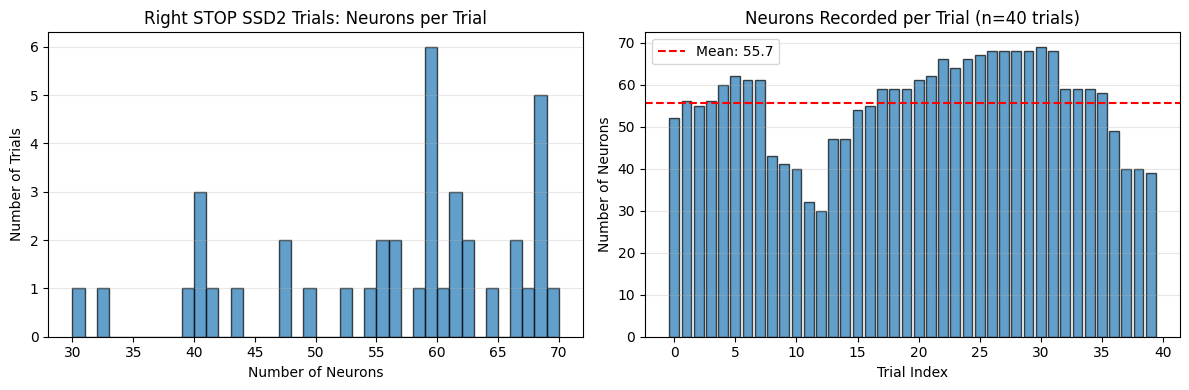



Trial-by-trial breakdown:
Trial 190: 52 neurons
Trial 216: 56 neurons
Trial 233: 55 neurons
Trial 248: 56 neurons
Trial 284: 60 neurons
Trial 296: 62 neurons
Trial 388: 61 neurons
Trial 393: 61 neurons
Trial 597: 43 neurons
Trial 618: 41 neurons
Trial 638: 40 neurons
Trial 709: 32 neurons
Trial 733: 30 neurons
Trial 886: 47 neurons
Trial 913: 47 neurons
Trial 1017: 54 neurons
Trial 1060: 55 neurons
Trial 1108: 59 neurons
Trial 1109: 59 neurons
Trial 1112: 59 neurons
Trial 1146: 61 neurons
Trial 1186: 62 neurons
Trial 1308: 66 neurons
Trial 1411: 64 neurons
Trial 1425: 66 neurons
Trial 1453: 67 neurons
Trial 1499: 68 neurons
Trial 1507: 68 neurons
Trial 1517: 68 neurons
Trial 1580: 68 neurons
Trial 1624: 69 neurons
Trial 1667: 68 neurons
Trial 1773: 59 neurons
Trial 1782: 59 neurons
Trial 1783: 59 neurons
Trial 1805: 58 neurons
Trial 1972: 49 neurons
Trial 2060: 40 neurons
Trial 2067: 40 neurons
Trial 2090: 39 neurons


In [9]:
# Parameters for analysis
analysis_trial_type = 'STOP'
analysis_direction = DIRECTION
analysis_ssd_num = SSD_NUM

# Filter trials using the filter function
filtered_data = filter_trials(
    session.data, 
    trial_type=analysis_trial_type, 
    direction=analysis_direction, 
    ssd_number=analysis_ssd_num,
    success_only=True
)

# Count unique cells per trial
neurons_per_trial = filtered_data.groupby('trial_number')['cell_ID'].nunique().sort_index()

# Summary statistics
dir_name = dir_map[analysis_direction]
print(f"{dir_name} {analysis_trial_type} SSD{analysis_ssd_num} Trials - Neurons per Trial Distribution:")
print("=" * 60)
print(f"Total trials: {len(neurons_per_trial)}")
print(f"Mean neurons per trial: {neurons_per_trial.mean():.2f}")
print(f"Median neurons per trial: {neurons_per_trial.median():.0f}")
print(f"Min neurons per trial: {neurons_per_trial.min()}")
print(f"Max neurons per trial: {neurons_per_trial.max()}")
print(f"\nDistribution:")
print(neurons_per_trial.value_counts().sort_index())

# Visualize distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax1.hist(neurons_per_trial, bins=range(neurons_per_trial.min(), neurons_per_trial.max() + 2), 
         edgecolor='black', alpha=0.7)
ax1.set_xlabel('Number of Neurons')
ax1.set_ylabel('Number of Trials')
ax1.set_title(f'{dir_name} {analysis_trial_type} SSD{analysis_ssd_num} Trials: Neurons per Trial')
ax1.grid(axis='y', alpha=0.3)

# Per-trial view
ax2.bar(range(len(neurons_per_trial)), neurons_per_trial.values, edgecolor='black', alpha=0.7)
ax2.set_xlabel('Trial Index')
ax2.set_ylabel('Number of Neurons')
ax2.set_title(f'Neurons Recorded per Trial (n={len(neurons_per_trial)} trials)')
ax2.axhline(y=neurons_per_trial.mean(), color='r', linestyle='--', label=f'Mean: {neurons_per_trial.mean():.1f}')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Show trial-by-trial details
print(f"\n\nTrial-by-trial breakdown:")
print("=" * 60)
for trial_num, n_neurons in neurons_per_trial.items():
    print(f"Trial {trial_num}: {n_neurons} neurons")

### 4.A Neuron-Trial Recording Heatmap

Visualize which neurons were recorded for each trial.

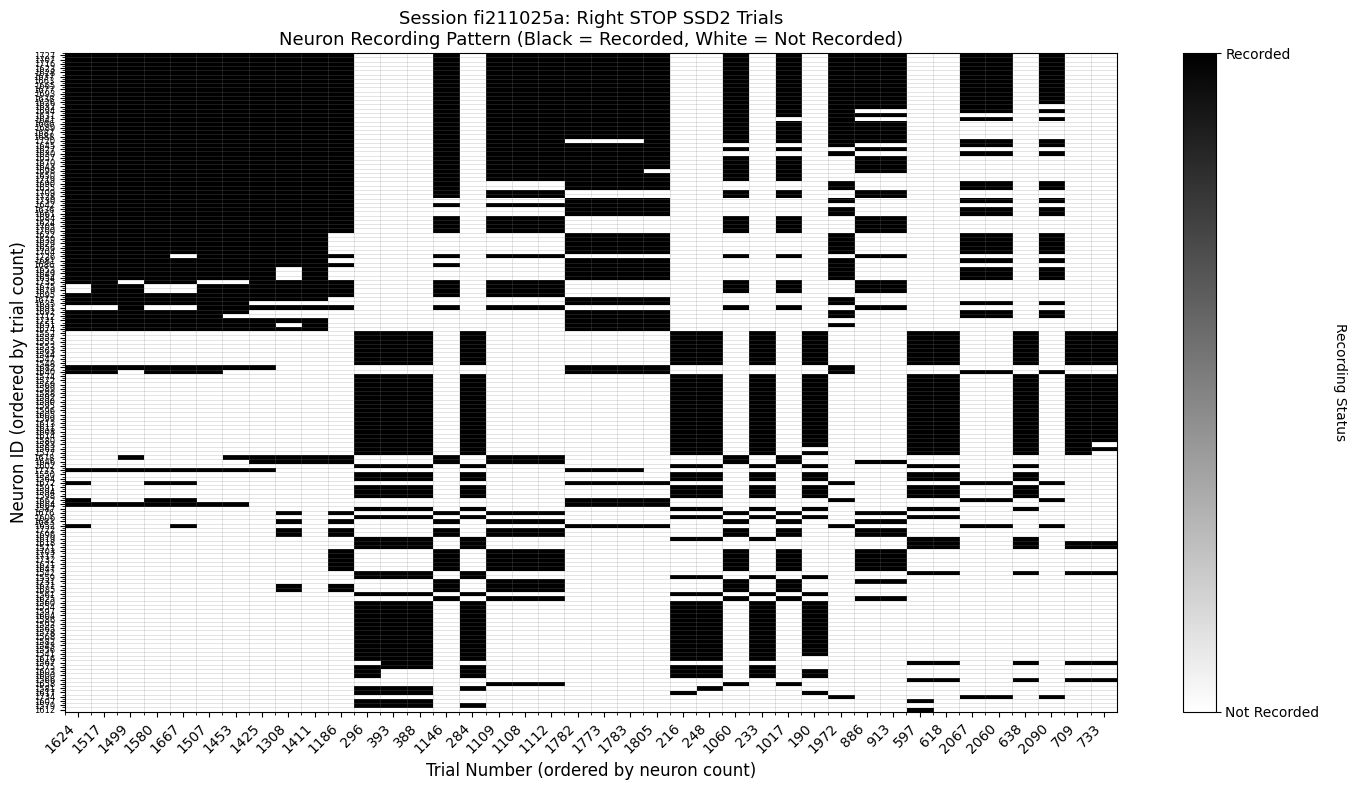


Recording Matrix Summary:
Session: fi211025a
Total neurons: 154
Total trials: 40
Total possible recordings: 6160
Actual recordings: 2227
Recording density: 36.15%

Neurons per trial: min=30, max=69, mean=55.7
Trials per neuron: min=1, max=27, mean=14.5

Trials ordered by neuron count (most to least):
[np.int64(1624), np.int64(1517), np.int64(1499), np.int64(1580), np.int64(1667), np.int64(1507), np.int64(1453), np.int64(1425), np.int64(1308), np.int64(1411), np.int64(1186), np.int64(296), np.int64(393), np.int64(388), np.int64(1146), np.int64(284), np.int64(1109), np.int64(1108), np.int64(1112), np.int64(1782), np.int64(1773), np.int64(1783), np.int64(1805), np.int64(216), np.int64(248), np.int64(1060), np.int64(233), np.int64(1017), np.int64(190), np.int64(1972), np.int64(886), np.int64(913), np.int64(597), np.int64(618), np.int64(2067), np.int64(2060), np.int64(638), np.int64(2090), np.int64(709), np.int64(733)]

Neurons ordered by trial count (most to least):
[np.int64(1727), np.in

In [10]:
def plot_neuron_trial_heatmap(filtered_data, session_id, trial_type, direction, ssd_number, dir_map,
                              figsize=(14, 8), show=True):
    """
    Create heatmap showing which neurons were recorded in which trials.

    Parameters:
    -----------
    filtered_data : DataFrame
        Filtered trial data
    session_id : str
        Session identifier
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 (right) or 180 (left)
    ssd_number : int
        SSD level
    dir_map : dict
        Direction mapping {0: 'Right', 180: 'Left'}
    figsize : tuple
        Figure size
    show : bool
        Whether to display the plot

    Returns:
    --------
    tuple : (fig, ax, recording_matrix, summary_stats, ordered_trial_numbers, ordered_cell_ids)
    """
    # Get unique trial numbers and cell IDs
    trial_numbers = sorted(filtered_data['trial_number'].unique())
    cell_ids = sorted(filtered_data['cell_ID'].unique())

    # Create binary matrix: 1 if neuron recorded in trial, 0 otherwise
    recording_matrix = np.zeros((len(cell_ids), len(trial_numbers)))

    # Fill matrix
    for i, cell_id in enumerate(cell_ids):
        for j, trial_num in enumerate(trial_numbers):
            exists = ((filtered_data['cell_ID'] == cell_id) &
                      (filtered_data['trial_number'] == trial_num)).any()
            recording_matrix[i, j] = 1 if exists else 0

    # Compute coverage
    neurons_per_trial = recording_matrix.sum(axis=0)  # For each trial (column)
    trials_per_neuron = recording_matrix.sum(axis=1)  # For each neuron (row)

    # Sort trials by neurons_per_trial (descending: most neurons first)
    trial_order = np.argsort(neurons_per_trial)[::-1]
    ordered_trial_numbers = [trial_numbers[i] for i in trial_order]

    # Sort neurons by trials_per_neuron (descending: most trials first)
    neuron_order = np.argsort(trials_per_neuron)[::-1]
    ordered_cell_ids = [cell_ids[i] for i in neuron_order]

    # Reorder the recording matrix
    recording_matrix_ordered = recording_matrix[neuron_order, :][:, trial_order]

    # Compute summary statistics (on reordered matrix)
    neurons_per_trial_ordered = recording_matrix_ordered.sum(axis=0)
    trials_per_neuron_ordered = recording_matrix_ordered.sum(axis=1)

    summary_stats = {
        'n_neurons': len(cell_ids),
        'n_trials': len(trial_numbers),
        'total_possible': len(cell_ids) * len(trial_numbers),
        'actual_recordings': int(recording_matrix_ordered.sum()),
        'recording_density': recording_matrix_ordered.mean(),
        'neurons_per_trial_min': int(neurons_per_trial_ordered.min()) if len(neurons_per_trial_ordered) > 0 else 0,
        'neurons_per_trial_max': int(neurons_per_trial_ordered.max()) if len(neurons_per_trial_ordered) > 0 else 0,
        'neurons_per_trial_mean': neurons_per_trial_ordered.mean() if len(neurons_per_trial_ordered) > 0 else 0,
        'trials_per_neuron_min': int(trials_per_neuron_ordered.min()) if len(trials_per_neuron_ordered) > 0 else 0,
        'trials_per_neuron_max': int(trials_per_neuron_ordered.max()) if len(trials_per_neuron_ordered) > 0 else 0,
        'trials_per_neuron_mean': trials_per_neuron_ordered.mean() if len(trials_per_neuron_ordered) > 0 else 0,
    }

    # Create heatmap
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(recording_matrix_ordered, aspect='auto', cmap='binary', interpolation='nearest')

    # Set ticks and labels
    ax.set_xticks(range(len(ordered_trial_numbers)))
    ax.set_xticklabels(ordered_trial_numbers, rotation=45, ha='right')
    ax.set_yticks(range(len(ordered_cell_ids)))
    ax.set_yticklabels(ordered_cell_ids, fontsize=max(6, min(10, 400 // len(ordered_cell_ids))))

    # Labels and title
    ax.set_xlabel('Trial Number (ordered by neuron count)', fontsize=12)
    ax.set_ylabel('Neuron ID (ordered by trial count)', fontsize=12)
    dir_name = dir_map[direction]
    ax.set_title(f'Session {session_id}: {dir_name} {trial_type} SSD{ssd_number} Trials\n' +
                 f'Neuron Recording Pattern (Black = Recorded, White = Not Recorded)', fontsize=13)

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Recording Status', rotation=270, labelpad=20)
    cbar.ax.set_yticklabels(['Not Recorded', 'Recorded'])

    # Add grid for better readability
    ax.set_xticks(np.arange(len(ordered_trial_numbers)) - 0.5, minor=True)
    ax.set_yticks(np.arange(len(ordered_cell_ids)) - 0.5, minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=0.5, alpha=0.3)

    plt.tight_layout()

    if show:
        plt.show()

    return fig, ax, recording_matrix_ordered, summary_stats, ordered_trial_numbers, ordered_cell_ids


# Use the function to plot heatmap for current session
filtered_data = filter_trials(
    session.data, 
    trial_type=analysis_trial_type, 
    direction=analysis_direction, 
    ssd_number=analysis_ssd_num,
    success_only=True
)

results = plot_neuron_trial_heatmap(
    filtered_data, 
    session_id, 
    analysis_trial_type, 
    analysis_direction, 
    analysis_ssd_num, 
    dir_map
)

# Unpack results (now includes ordered lists)
fig, ax, recording_matrix, summary_stats, ordered_trial_numbers, ordered_cell_ids = results

# Print summary statistics
print(f"\nRecording Matrix Summary:")
print("=" * 60)
print(f"Session: {session_id}")
print(f"Total neurons: {summary_stats['n_neurons']}")
print(f"Total trials: {summary_stats['n_trials']}")
print(f"Total possible recordings: {summary_stats['total_possible']}")
print(f"Actual recordings: {summary_stats['actual_recordings']}")
print(f"Recording density: {summary_stats['recording_density']:.2%}")
print(f"\nNeurons per trial: min={summary_stats['neurons_per_trial_min']}, "
      f"max={summary_stats['neurons_per_trial_max']}, "
      f"mean={summary_stats['neurons_per_trial_mean']:.1f}")
print(f"Trials per neuron: min={summary_stats['trials_per_neuron_min']}, "
      f"max={summary_stats['trials_per_neuron_max']}, "
      f"mean={summary_stats['trials_per_neuron_mean']:.1f}")
print(f"\nTrials ordered by neuron count (most to least):")
print(ordered_trial_numbers)
print(f"\nNeurons ordered by trial count (most to least):")
print(ordered_cell_ids)

## 5. Session Comparison

Compare recording density across all valid sessions to find the best session for analysis.

In [11]:
def compute_session_recording_density(session_df, trial_type, direction, ssd_number, success_only=True):
    """
    Compute recording density for a session.
    
    Parameters:
    -----------
    session_df : DataFrame
        Session data
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 or 180
    ssd_number : int
        SSD level
    success_only : bool
        Only successful trials
        
    Returns:
    --------
    dict : Statistics including recording density
    """
    # Filter trials
    filtered = filter_trials(session_df, trial_type, direction, ssd_number, success_only)
    
    if len(filtered) == 0:
        return {
            'n_neurons': 0,
            'n_trials': 0,
            'total_possible': 0,
            'actual_recordings': 0,
            'recording_density': 0.0,
            'expected_density': 0.0
        }
    
    # Get unique neurons and trials
    n_neurons = filtered['cell_ID'].nunique()
    n_trials = filtered['trial_number'].nunique()
    total_possible = n_neurons * n_trials
    actual_recordings = len(filtered)
    recording_density = actual_recordings / total_possible if total_possible > 0 else 0.0
    expected_density = recording_density * n_neurons
    
    return {
        'n_neurons': n_neurons,
        'n_trials': n_trials,
        'total_possible': total_possible,
        'actual_recordings': actual_recordings,
        'recording_density': recording_density,
        'expected_density': expected_density
    }



print("Creating pca_analyzer object...")
pca_analyzer = MultiSessionPCA()
pca_analyzer.load_data(pickle_file)
pca_analyzer.get_session_statistics()
pca_analyzer.validate_all_sessions(verbose=False)
print(f"Validated {len(pca_analyzer.valid_sessions)} sessions")

# Analyze all valid sessions
print("\nComputing recording density for all valid sessions...")
print("=" * 80)

session_comparison = []

for idx, row in pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].iterrows():
    sess_id = row['session_id']
    
    # Get session data
    sess_data = cell_df[cell_df['trial_session'] == sess_id]
    
    # Create Session object and drop incomplete cells
    sess_obj = Session(sess_data, verbose=False)
    sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
    
    # Compute stats for both directions
    for direction in [0, 180]:
        stats = compute_session_recording_density(
            sess_obj.data, 
            trial_type='STOP', 
            direction=direction, 
            ssd_number=SSD_NUM, 
            success_only=True
        )
        
        if stats['n_trials'] > 0:  # Only include if there are trials
            session_comparison.append({
                'session_id': sess_id,
                'direction': dir_map[direction],
                'n_neurons': stats['n_neurons'],
                'n_trials': stats['n_trials'],
                'total_possible': stats['total_possible'],
                'actual_recordings': stats['actual_recordings'],
                'recording_density': stats['recording_density'],
                'expected_density': stats['expected_density']
            })

# Create DataFrame
comparison_df = pd.DataFrame(session_comparison)
comparison_df = comparison_df.sort_values('expected_density', ascending=False)

# Summary statistics
print(f"\nTop 10 Sessions by Expected Density:")
print("=" * 80)
top_10 = comparison_df.head(10)[['session_id', 'direction', 'n_neurons', 'n_trials', 
                                   'recording_density', 'expected_density']].copy()
top_10['recording_density'] = top_10['recording_density'].apply(lambda x: f"{x:.2%}")
print(top_10.to_string(index=False))

# Find absolute best
best_row = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"BEST CONFIGURATION:")
print(f"  Session: {best_row['session_id']}")
print(f"  Direction: {best_row['direction']}")
print(f"  Neurons: {best_row['n_neurons']}")
print(f"  Trials: {best_row['n_trials']}")
print(f"  Recording Density: {best_row['recording_density']:.2%}")
print(f"  Expected Density: {best_row['expected_density']:.2f}")
print(f"{'='*80}")

Creating pca_analyzer object...
Loading data from: /home/barak/Projects/population-analysis/data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl
✓ Database loaded: 1,939,269 cell-trial combinations
  Total sessions: 61
  Total unique cells: 3096
✓ Session statistics computed for 61 sessions
  Excluded sessions: 1
  Candidate sessions: 60
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Cell 1352 removed from session fi211018a.
Dropped 1 cell with incomplete trial type or directional data.
Validated 51 sessions

Computing recording density for all valid sessions...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Cell 1352 removed from session fi211018a.
Dropped 1 cell with incomplete trial type or directional data.

Top 10 Sessions by Expected Density:
session_id direction  n_neurons  n_trials recording_density  expected_density
 fi211025a     Right        154        40

### 5.1 Add Neural Tuning Analysis

Test neurons for task and direction tuning using ANOVA.

In [12]:
from scipy import stats

# Analysis windows (from tuning analysis methodology)
TUNING_WINDOWS = {
    'baseline': [-200, 0],  # Pre-cue baseline (changed from -500)
    'task': [0, 500],  # Task execution
    'direction': [0, 500],  # Movement period for direction tuning
    'stop_vs_go_original': {
        'go': [100, 300],  # GO trials: 100-300ms post go-cue
        'stop': [0, 200]   # STOP trials: 0-200ms post stop-cue
    },
    'stop_vs_go_matched': {
        'go': None,  # Will be [0, mean_SSD] from go-cue
        'stop': None  # Will be [0, mean_SSD] from stop-cue
    }
}

def get_firing_rates(cell, align_event, window, trial_type=None, direction=None, success_only=True, ssd_number=None):
    """
    Extract firing rates for specific conditions.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    align_event : str
        'go_cue' or 'stop_cue'
    window : list
        Time window [start, end] in ms
    trial_type : str, optional
        'GO', 'STOP', or 'CONT'
    direction : int, optional
        0 (right) or 180 (left)
    success_only : bool
        Include only successful trials
    ssd_number : int, optional
        SSD level for STOP/CONT trials
    
    Returns:
    --------
    np.array : Firing rates in spikes/sec
    """
    df = cell.filter_trials(trial_type=trial_type, direction=direction, success_only=success_only)
    
    # Add SSD filter if specified
    if ssd_number is not None:
        df = df[df['ssd_number'] == ssd_number]
    
    rates = []
    for _, row in df.iterrows():
        if align_event == 'go_cue':
            t0 = row['go_cue']
        elif align_event == 'stop_cue':
            t0 = row['stop_cue']
        else:
            raise ValueError(f"Unknown align_event: {align_event}")
        
        if pd.isna(t0):
            continue
            
        spikes = np.array(row['neural_data'], dtype=float)
        aligned_spikes = spikes - t0
        
        count = np.sum((aligned_spikes >= window[0]) & (aligned_spikes <= window[1]))
        duration = (window[1] - window[0]) / 1000.0
        rates.append(count / duration)
        
    return np.array(rates)


def test_cell_tuning(cell, alpha=0.05, ssd_number=2):
    """
    Test if a cell is tuned to task, direction, and/or STOP signal.
    
    Parameters:
    -----------
    cell : Cell
        Cell object
    alpha : float
        Significance threshold (default: 0.05)
    ssd_number : int
        SSD level for STOP trials (default: 2)
        
    Returns:
    --------
    dict : Tuning test results
    """
    results = {
        'cell_id': cell.cell_id,
        'task_modulated': False,
        'direction_tuned': False,
        'stop_sensitive_original': False,
        'stop_sensitive_matched': False,
        'task_p': np.nan,
        'direction_p': np.nan,
        'stop_original_p': np.nan,
        'stop_matched_p': np.nan,
    }
    
    # Test 1: Task modulation (baseline vs GO period)
    try:
        baseline = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['baseline'], trial_type='GO')
        task = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['task'], trial_type='GO')
        
        if len(baseline) >= 5 and len(task) >= 5:
            _, p_val = stats.f_oneway(baseline, task)
            results['task_p'] = p_val
            results['task_modulated'] = p_val < alpha
    except:
        pass
    
    # Test 2: Direction tuning (left vs right during GO trials)
    try:
        go_left = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['direction'], trial_type='GO', direction=180)
        go_right = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['direction'], trial_type='GO', direction=0)
        
        if len(go_left) >= 5 and len(go_right) >= 5:
            _, p_val = stats.f_oneway(go_left, go_right)
            results['direction_p'] = p_val
            results['direction_tuned'] = p_val < alpha
    except:
        pass
    
    # Test 3: STOP sensitivity - Original proposal
    # GO trials: [100, 300]ms from go-cue vs STOP trials: [0, 200]ms from stop-cue
    try:
        go_rates = get_firing_rates(cell, 'go_cue', TUNING_WINDOWS['stop_vs_go_original']['go'], 
                                    trial_type='GO')
        stop_rates = get_firing_rates(cell, 'stop_cue', TUNING_WINDOWS['stop_vs_go_original']['stop'], 
                                      trial_type='STOP', ssd_number=ssd_number)
        
        if len(go_rates) >= 5 and len(stop_rates) >= 3:  # Relaxed threshold for STOP trials
            _, p_val = stats.f_oneway(go_rates, stop_rates)
            results['stop_original_p'] = p_val
            results['stop_sensitive_original'] = p_val < alpha
    except:
        pass
    
    # Test 4: STOP sensitivity - Time-matched proposal
    # GO trials: [0, mean_SSD]ms from go-cue vs STOP trials: [0, mean_SSD]ms from stop-cue
    try:
        # Get mean SSD for this cell's STOP trials
        stop_df = cell.filter_trials(trial_type='STOP', success_only=True)
        stop_df = stop_df[stop_df['ssd_number'] == ssd_number]
        
        if len(stop_df) > 0:
            mean_ssd = stop_df['ssd_len'].mean()
            
            go_rates = get_firing_rates(cell, 'go_cue', [0, mean_ssd], trial_type='GO')
            stop_rates = get_firing_rates(cell, 'stop_cue', [0, mean_ssd], 
                                          trial_type='STOP', ssd_number=ssd_number)
            
            if len(go_rates) >= 5 and len(stop_rates) >= 3:
                _, p_val = stats.f_oneway(go_rates, stop_rates)
                results['stop_matched_p'] = p_val
                results['stop_sensitive_matched'] = p_val < alpha
    except:
        pass
    
    # Overall tuning status
    results['is_tuned'] = (results['task_modulated'] or 
                           results['direction_tuned'] or 
                           results['stop_sensitive_original'] or 
                           results['stop_sensitive_matched'])
    
    return results


def compute_session_tuning_stats(session, alpha=0.05, ssd_number=2):
    """
    Compute tuning statistics for all cells in a session.
    
    Parameters:
    -----------
    session : Session
        Session object
    alpha : float
        Significance threshold
    ssd_number : int
        SSD level for STOP trials
        
    Returns:
    --------
    dict : Session-level tuning statistics
    """
    tuning_results = []
    
    for cell_id in session.cell_ids:
        try:
            cell = session.get_cell(cell_id)
            result = test_cell_tuning(cell, alpha=alpha, ssd_number=ssd_number)
            tuning_results.append(result)
        except:
            continue
    
    if len(tuning_results) == 0:
        return {
            'n_cells': 0,
            'n_task_modulated': 0,
            'n_direction_tuned': 0,
            'n_stop_sensitive_original': 0,
            'n_stop_sensitive_matched': 0,
            'n_tuned': 0,
            'pct_task_modulated': 0.0,
            'pct_direction_tuned': 0.0,
            'pct_stop_sensitive_original': 0.0,
            'pct_stop_sensitive_matched': 0.0,
            'pct_tuned': 0.0,
        }
    
    n_cells = len(tuning_results)
    n_task = sum(r['task_modulated'] for r in tuning_results)
    n_direction = sum(r['direction_tuned'] for r in tuning_results)
    n_stop_orig = sum(r['stop_sensitive_original'] for r in tuning_results)
    n_stop_match = sum(r['stop_sensitive_matched'] for r in tuning_results)
    n_tuned = sum(r['is_tuned'] for r in tuning_results)
    
    return {
        'n_cells': n_cells,
        'n_task_modulated': n_task,
        'n_direction_tuned': n_direction,
        'n_stop_sensitive_original': n_stop_orig,
        'n_stop_sensitive_matched': n_stop_match,
        'n_tuned': n_tuned,
        'pct_task_modulated': 100 * n_task / n_cells,
        'pct_direction_tuned': 100 * n_direction / n_cells,
        'pct_stop_sensitive_original': 100 * n_stop_orig / n_cells,
        'pct_stop_sensitive_matched': 100 * n_stop_match / n_cells,
        'pct_tuned': 100 * n_tuned / n_cells,
    }

print("✓ Tuning analysis functions defined (with STOP sensitivity tests)")
print("  - Baseline window: [-200, 0]ms")
print("  - STOP matched test: GO [0, mean_SSD] vs STOP [0, mean_SSD]")

✓ Tuning analysis functions defined (with STOP sensitivity tests)
  - Baseline window: [-200, 0]ms
  - STOP matched test: GO [0, mean_SSD] vs STOP [0, mean_SSD]


### 5.2 Get STOP-Tuned Neurons

Use the new functions to get lists of STOP-tuned neurons per session and direction.

In [13]:
def get_stop_tuned_neurons(session, direction=None, ssd_number=2, test_type='both', alpha=0.05):
    """
    Get list of STOP-tuned neuron IDs for a given session and direction.
    
    Parameters:
    -----------
    session : Session
        Session object containing neuron data
    direction : int, optional
        Direction to filter by (0 for right, 180 for left)
        If None, returns neurons tuned for any direction
    ssd_number : int
        SSD level for STOP trials (default: 2)
    test_type : str
        Which STOP sensitivity test to use:
        - 'original': GO [100-300ms] vs STOP [0-200ms from stop_cue]
        - 'matched': GO [0-mean_SSD] vs STOP [0-mean_SSD from stop_cue]
        - 'both': Either test (default)
    alpha : float
        Significance threshold (default: 0.05)
    
    Returns:
    --------
    list : List of cell IDs that are STOP-tuned
    """
    stop_tuned_neurons = []
    
    for cell_id in session.cell_ids:
        try:
            cell = session.get_cell(cell_id)
            
            # If direction is specified, check if cell has data for that direction
            if direction is not None:
                direction_data = cell.filter_trials(
                    trial_type='STOP',
                    direction=direction,
                    success_only=True
                )
                direction_data = direction_data[direction_data['ssd_number'] == ssd_number]
                
                # Skip if no data for this direction
                if len(direction_data) == 0:
                    continue
            
            # Run tuning test
            result = test_cell_tuning(cell, alpha=alpha, ssd_number=ssd_number)
            
            # Check if neuron is STOP-tuned based on test_type
            is_stop_tuned = False
            if test_type == 'original':
                is_stop_tuned = result['stop_sensitive_original']
            elif test_type == 'matched':
                is_stop_tuned = result['stop_sensitive_matched']
            elif test_type == 'both':
                is_stop_tuned = result['stop_sensitive_original'] or result['stop_sensitive_matched']
            else:
                raise ValueError(f"Unknown test_type: {test_type}. Use 'original', 'matched', or 'both'")
            
            if is_stop_tuned:
                stop_tuned_neurons.append(cell_id)
                
        except Exception as e:
            # Skip cells that fail tuning test
            continue
    
    return stop_tuned_neurons


def get_stop_tuned_neurons_all_sessions(cell_df, session_ids=None, direction=None, 
                                         ssd_number=2, test_type='both', alpha=0.05, 
                                         verbose=True):
    """
    Get STOP-tuned neurons across multiple sessions.
    
    Parameters:
    -----------
    cell_df : DataFrame
        Full cell database
    session_ids : list, optional
        List of session IDs to analyze. If None, analyzes all sessions
    direction : int, optional
        Direction to filter by (0 for right, 180 for left)
        If None, returns neurons tuned for any direction
    ssd_number : int
        SSD level for STOP trials (default: 2)
    test_type : str
        Which STOP sensitivity test to use ('original', 'matched', or 'both')
    alpha : float
        Significance threshold (default: 0.05)
    verbose : bool
        Print progress messages (default: True)
    
    Returns:
    --------
    dict : Dictionary mapping session_id to list of STOP-tuned cell IDs
    """
    results = {}
    
    # Get all sessions if not specified
    if session_ids is None:
        session_ids = cell_df['trial_session'].unique()
    
    for sess_id in session_ids:
        if verbose:
            print(f"Processing session {sess_id}...")
        
        try:
            # Create session object
            sess_data = cell_df[cell_df['trial_session'] == sess_id]
            sess_obj = Session(sess_data, verbose=False)
            sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
            
            # Get STOP-tuned neurons
            stop_neurons = get_stop_tuned_neurons(
                sess_obj, 
                direction=direction, 
                ssd_number=ssd_number, 
                test_type=test_type, 
                alpha=alpha
            )
            
            results[sess_id] = stop_neurons
            
            if verbose:
                dir_str = f"direction {direction}" if direction is not None else "all directions"
                print(f"  Found {len(stop_neurons)} STOP-tuned neurons ({dir_str})")
                
        except Exception as e:
            if verbose:
                print(f"  Error processing session {sess_id}: {e}")
            results[sess_id] = []
    
    return results


print("✓ STOP-tuned neuron query functions defined")
print("  - get_stop_tuned_neurons(): Get STOP-tuned neurons for a single session")
print("  - get_stop_tuned_neurons_all_sessions(): Get STOP-tuned neurons across all sessions")

✓ STOP-tuned neuron query functions defined
  - get_stop_tuned_neurons(): Get STOP-tuned neurons for a single session
  - get_stop_tuned_neurons_all_sessions(): Get STOP-tuned neurons across all sessions


In [14]:
# Example 1: Get STOP-tuned neurons for current session, right direction (0°)
print("=" * 80)
print("Example 1: STOP-tuned neurons for current session (Right direction)")
print("=" * 80)

stop_neurons_right = get_stop_tuned_neurons(
    session, 
    direction=0,  # Right direction
    ssd_number=SSD_NUM,
    test_type='both',  # Either test
    alpha=0.05
)

print(f"\nSession: {session_id}")
print(f"Direction: Right (0°)")
print(f"SSD Level: {SSD_NUM}")
print(f"STOP-tuned neurons found: {len(stop_neurons_right)}")
print(f"Cell IDs: {stop_neurons_right}")

# Example 2: Get STOP-tuned neurons for current session, left direction (180°)
print("\n" + "=" * 80)
print("Example 2: STOP-tuned neurons for current session (Left direction)")
print("=" * 80)

stop_neurons_left = get_stop_tuned_neurons(
    session, 
    direction=180,  # Left direction
    ssd_number=SSD_NUM,
    test_type='both',
    alpha=0.05
)

print(f"\nSession: {session_id}")
print(f"Direction: Left (180°)")
print(f"SSD Level: {SSD_NUM}")
print(f"STOP-tuned neurons found: {len(stop_neurons_left)}")
print(f"Cell IDs: {stop_neurons_left}")

# Example 3: Get STOP-tuned neurons for current session, any direction
print("\n" + "=" * 80)
print("Example 3: STOP-tuned neurons for current session (Any direction)")
print("=" * 80)

stop_neurons_any = get_stop_tuned_neurons(
    session, 
    direction=None,  # Any direction
    ssd_number=SSD_NUM,
    test_type='both',
    alpha=0.05
)

print(f"\nSession: {session_id}")
print(f"Direction: Any")
print(f"SSD Level: {SSD_NUM}")
print(f"STOP-tuned neurons found: {len(stop_neurons_any)}")
print(f"Cell IDs: {stop_neurons_any}")

# Summary comparison
print("\n" + "=" * 80)
print("Summary Comparison")
print("=" * 80)
print(f"Right only: {len(stop_neurons_right)} neurons")
print(f"Left only: {len(stop_neurons_left)} neurons")
print(f"Any direction: {len(stop_neurons_any)} neurons")

Example 1: STOP-tuned neurons for current session (Right direction)

Session: fi211025a
Direction: Right (0°)
SSD Level: 2
STOP-tuned neurons found: 39
Cell IDs: [np.int64(1541), np.int64(1543), np.int64(1547), np.int64(1556), np.int64(1557), np.int64(1559), np.int64(1560), np.int64(1561), np.int64(1567), np.int64(1568), np.int64(1572), np.int64(1574), np.int64(1588), np.int64(1589), np.int64(1590), np.int64(1591), np.int64(1593), np.int64(1594), np.int64(1596), np.int64(1599), np.int64(1622), np.int64(1626), np.int64(1628), np.int64(1629), np.int64(1636), np.int64(1639), np.int64(1654), np.int64(1670), np.int64(1676), np.int64(1679), np.int64(1681), np.int64(1686), np.int64(1687), np.int64(1692), np.int64(1694), np.int64(1695), np.int64(1698), np.int64(1712), np.int64(1731)]

Example 2: STOP-tuned neurons for current session (Left direction)

Session: fi211025a
Direction: Left (180°)
SSD Level: 2
STOP-tuned neurons found: 39
Cell IDs: [np.int64(1541), np.int64(1543), np.int64(1547), n

In [15]:
# Example 4: Get STOP-tuned neurons across all valid sessions (Right direction)
print("=" * 80)
print("Example 4: STOP-tuned neurons across all valid sessions (Right direction)")
print("=" * 80)

# Get valid session IDs from pca_analyzer (if it exists)
try:
    valid_session_ids = pca_analyzer.valid_sessions
    print(f"\nAnalyzing {len(valid_session_ids)} valid sessions...")
    print("(This may take a minute...)\n")
except NameError:
    # If pca_analyzer doesn't exist, use a subset of sessions for demo
    print("\nNote: Using subset of sessions for demo. Run cell 21 first for all sessions.\n")
    valid_session_ids = [session_id]  # Just use current session

# Get STOP-tuned neurons for all sessions (Right direction)
stop_neurons_by_session = get_stop_tuned_neurons_all_sessions(
    cell_df,
    session_ids=valid_session_ids,
    direction=0,  # Right direction
    ssd_number=SSD_NUM,
    test_type='both',
    alpha=0.05,
    verbose=True
)

# Create summary DataFrame
summary_data = []
for sess_id, neurons in stop_neurons_by_session.items():
    summary_data.append({
        'session_id': sess_id,
        'n_stop_tuned': len(neurons),
        'cell_ids': neurons
    })

summary_df = pd.DataFrame(summary_data).sort_values('n_stop_tuned', ascending=False)

# Display top sessions
print("\n" + "=" * 80)
print("Top 10 Sessions by Number of STOP-Tuned Neurons (Right direction)")
print("=" * 80)
top_sessions = summary_df.head(10)[['session_id', 'n_stop_tuned']].copy()
print(top_sessions.to_string(index=False))

print(f"\n✓ Total sessions analyzed: {len(summary_df)}")
print(f"✓ Total STOP-tuned neurons found: {summary_df['n_stop_tuned'].sum()}")

Example 4: STOP-tuned neurons across all valid sessions (Right direction)

Analyzing 51 valid sessions...
(This may take a minute...)

Processing session fi211102a...
  Found 34 STOP-tuned neurons (direction 0)
Processing session fi211025a...
  Found 39 STOP-tuned neurons (direction 0)
Processing session fi211110a...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
  Found 13 STOP-tuned neurons (direction 0)
Processing session fi211122a...
  Found 17 STOP-tuned neurons (direction 0)
Processing session fi211109a...
  Found 22 STOP-tuned neurons (direction 0)
Processing session fi211111a...
  Found 23 STOP-tuned neurons (direction 0)
Processing session fi211104a...
  Found 25 STOP-tuned neurons (direction 0)
Processing session fi211026a...
  Found 14 STOP-tuned neurons (direction 0)
Processing session fi211115a...
  Found 36 STOP-tuned neurons (direction 0)
Processing session fi211108a...
  Found 12 STOP-tuned neurons (direction 0)


In [16]:
(stop_neurons_by_session['fi211025a'])

[np.int64(1541),
 np.int64(1543),
 np.int64(1547),
 np.int64(1556),
 np.int64(1557),
 np.int64(1559),
 np.int64(1560),
 np.int64(1561),
 np.int64(1567),
 np.int64(1568),
 np.int64(1572),
 np.int64(1574),
 np.int64(1588),
 np.int64(1589),
 np.int64(1590),
 np.int64(1591),
 np.int64(1593),
 np.int64(1594),
 np.int64(1596),
 np.int64(1599),
 np.int64(1622),
 np.int64(1626),
 np.int64(1628),
 np.int64(1629),
 np.int64(1636),
 np.int64(1639),
 np.int64(1654),
 np.int64(1670),
 np.int64(1676),
 np.int64(1679),
 np.int64(1681),
 np.int64(1686),
 np.int64(1687),
 np.int64(1692),
 np.int64(1694),
 np.int64(1695),
 np.int64(1698),
 np.int64(1712),
 np.int64(1731)]

In [17]:
stop_neurons_by_session.keys()
stop_right_neurons_by_session = stop_neurons_by_session
stop_left_neurons_by_session = get_stop_tuned_neurons_all_sessions(
    cell_df,
    session_ids=valid_session_ids,
    direction=180,  # Left direction
    ssd_number=SSD_NUM,
    test_type='both',
    alpha=0.05,
    verbose=True
)

Processing session fi211102a...
  Found 34 STOP-tuned neurons (direction 180)
Processing session fi211025a...
  Found 39 STOP-tuned neurons (direction 180)
Processing session fi211110a...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
  Found 13 STOP-tuned neurons (direction 180)
Processing session fi211122a...
  Found 17 STOP-tuned neurons (direction 180)
Processing session fi211109a...
  Found 22 STOP-tuned neurons (direction 180)
Processing session fi211111a...
  Found 23 STOP-tuned neurons (direction 180)
Processing session fi211104a...
  Found 25 STOP-tuned neurons (direction 180)
Processing session fi211026a...
  Found 14 STOP-tuned neurons (direction 180)
Processing session fi211115a...
  Found 36 STOP-tuned neurons (direction 180)
Processing session fi211108a...
  Found 12 STOP-tuned neurons (direction 180)
Processing session fi211018a...
Cell 1352 removed from session fi211018a.
Dropped 1 cell with incomplete trial type

In [18]:
# Flatten all STOP-tuned neuron lists from all sessions (Right direction)
all_stop_right_neurons = [neuron for neurons_list in stop_right_neurons_by_session.values() for neuron in neurons_list]

print(f"Total STOP-tuned neurons across all sessions (Right direction): {len(all_stop_right_neurons)}")
print(f"Unique STOP-tuned neurons: {len(set(all_stop_right_neurons))}")
print(f"\nFirst 20 neurons: {all_stop_right_neurons[:20]}")

Total STOP-tuned neurons across all sessions (Right direction): 587
Unique STOP-tuned neurons: 587

First 20 neurons: [np.int64(1841), np.int64(1847), np.int64(1848), np.int64(1856), np.int64(1861), np.int64(1862), np.int64(1863), np.int64(1864), np.int64(1888), np.int64(1889), np.int64(1890), np.int64(1899), np.int64(1905), np.int64(1906), np.int64(1921), np.int64(3063), np.int64(3066), np.int64(3068), np.int64(3069), np.int64(3075)]


In [19]:
from scipy.stats import ranksums

from scipy.stats import ranksums
import numpy as np
import pandas as pd

def wilcoxon_ranksum_test_neuron(cell, direction, alpha=0.05, ssd_number=2):
    """
    Perform Wilcoxon rank-sum test comparing GO vs STOP firing rates for a single neuron.
    
    This test compares firing rates in the first 600ms after go_cue for:
    - GO trials in the specified direction
    - STOP trials in the specified direction (with specified SSD number)
    
    Parameters:
    -----------
    cell : Cell
        Cell object containing neuron data
    direction : int
        Direction to test (0 for right, 180 for left)
    alpha : float
        Significance threshold (default: 0.05)
    ssd_number : int
        SSD level for STOP trials (default: 2)
        
    Returns:
    --------
    dict : Dictionary containing:
        - cell_id: Neuron identifier
        - direction: Direction tested
        - go_firing_rates: Array of GO trial firing rates (spikes/sec)
        - stop_firing_rates: Array of STOP trial firing rates (spikes/sec)
        - n_go_trials: Number of GO trials
        - n_stop_trials: Number of STOP trials
        - p_value: Wilcoxon rank-sum test p-value
        - is_significant: Boolean indicating if p < alpha
    """
    
    # Time window for analysis (600ms = 0.6 seconds)
    window_start = 0
    window_end = 600
    window_duration = (window_end - window_start) / 1000  # seconds
    
    # Get GO trials for specified direction
    go_data = cell.filter_trials(
        trial_type='GO',
        direction=direction,
        success_only=True
    )
    
    # Get STOP trials for specified direction and SSD
    stop_data = cell.filter_trials(
        trial_type='STOP',
        direction=direction,
        success_only=True
    )
    stop_data = stop_data[stop_data['ssd_number'] == ssd_number]
    
    def calculate_firing_rate(row):
        go_cue = row['go_cue']
        if pd.isna(go_cue):
            return np.nan
            
        spikes = np.array(row['neural_data'], dtype=float)
        aligned_spikes = spikes - go_cue
        
        # Count spikes in [0, 600]ms window
        spike_count = np.sum((aligned_spikes >= window_start) & (aligned_spikes <= window_end))
        firing_rate = spike_count / window_duration
        return firing_rate
    
    # Calculate firing rates for GO trials using apply
    go_firing_rates = go_data.apply(calculate_firing_rate, axis=1).dropna().values
    
    # Calculate firing rates for STOP trials using apply
    stop_firing_rates = stop_data.apply(calculate_firing_rate, axis=1).dropna().values
    
    # Perform Wilcoxon rank-sum test (Mann-Whitney U test)
    if len(go_firing_rates) >= 3 and len(stop_firing_rates) >= 3:
        statistic, p_value = ranksums(go_firing_rates, stop_firing_rates)
    else:
        p_value = np.nan
        statistic = np.nan
    
    return {
        'cell_id': cell.cell_id,
        'direction': direction,
        'go_firing_rates': go_firing_rates,
        'stop_firing_rates': stop_firing_rates,
        'n_go_trials': len(go_firing_rates),
        'n_stop_trials': len(stop_firing_rates),
        'statistic': statistic,
        'p_value': p_value,
        'is_significant': p_value < alpha if not np.isnan(p_value) else False
    }


print("✓ Wilcoxon rank-sum test function defined")
print("  - Compares GO vs STOP firing rates in first 600ms after go_cue")
print("  - Uses scipy.stats.ranksums (equivalent to Mann-Whitney U test)")
print("  - Returns p-value and significance flag")
print("  - Optimized with apply() instead of iterrows()")


✓ Wilcoxon rank-sum test function defined
  - Compares GO vs STOP firing rates in first 600ms after go_cue
  - Uses scipy.stats.ranksums (equivalent to Mann-Whitney U test)
  - Returns p-value and significance flag
  - Optimized with apply() instead of iterrows()


In [20]:
# Test Wilcoxon rank-sum test on a neuron from all_stop_right_neurons

# Pick first neuron from the list
test_neuron_id = stop_right_neurons_by_session[session.session_id][0]

# Get cell object
test_cell = session.get_cell(test_neuron_id)

# Run Wilcoxon rank-sum test
# Pick a STOP-tuned neuron from the current session (fi211025a)
test_neuron_id = stop_neurons_right[0]  # This is from current session

# Get cell object
test_cell = session.get_cell(test_neuron_id)

# Run Wilcoxon rank-sum test
result = wilcoxon_ranksum_test_neuron(
    cell=test_cell,
    direction=0,  # Right direction
    alpha=0.05,
    ssd_number=SSD_NUM
)

# Display results
print("=" * 80)
print(f"Wilcoxon Rank-Sum Test Results for Neuron {test_neuron_id}")
print("=" * 80)
print(f"\nCell ID: {result['cell_id']}")
print(f"Direction: {dir_map[result['direction']]}")
print(f"\nGO trials: {result['n_go_trials']} trials")
print(f"  Mean firing rate: {result['go_firing_rates'].mean():.2f} spikes/sec")
print(f"  Std firing rate: {result['go_firing_rates'].std():.2f} spikes/sec")
print(f"\nSTOP trials: {result['n_stop_trials']} trials")
print(f"  Mean firing rate: {result['stop_firing_rates'].mean():.2f} spikes/sec")
print(f"  Std firing rate: {result['stop_firing_rates'].std():.2f} spikes/sec")
print(f"\nTest statistic: {result['statistic']:.4f}")
print(f"P-value: {result['p_value']:.6f}")
print(f"Significant at α=0.05: {result['is_significant']}")
print("=" * 80)

Wilcoxon Rank-Sum Test Results for Neuron 1541

Cell ID: 1541
Direction: Right

GO trials: 101 trials
  Mean firing rate: 0.54 spikes/sec
  Std firing rate: 0.88 spikes/sec

STOP trials: 8 trials
  Mean firing rate: 0.62 spikes/sec
  Std firing rate: 0.81 spikes/sec

Test statistic: -0.3137
P-value: 0.753728
Significant at α=0.05: False


In [21]:
# Initialize list to store all test results
all_wilcoxon_results = []

print(f"Running Wilcoxon rank-sum tests on STOP-tuned neurons (Right direction)...")
print("=" * 80)

# Iterate through each session in the dictionary
for sess_id, neuron_list in stop_right_neurons_by_session.items():
    if not neuron_list:
        continue
        
    print(f"Processing session {sess_id} ({len(neuron_list)} neurons)...")
    
    # Load session data
    try:
        sess_data = cell_df[cell_df['trial_session'] == sess_id]
        sess_obj = Session(sess_data, verbose=False)
        sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
        
        # Test each neuron in this session
        for cell_id in neuron_list:
            try:
                cell = sess_obj.get_cell(cell_id)
                
                # Run test
                result = wilcoxon_ranksum_test_neuron(
                    cell=cell,
                    direction=0,  # Right direction
                    alpha=0.05,
                    ssd_number=SSD_NUM
                )
                
                # Add session info to result
                result['session_id'] = sess_id
                all_wilcoxon_results.append(result)
                
            except Exception as e:
                print(f"  Error testing cell {cell_id}: {e}")
                continue
                
    except Exception as e:
        print(f"  Error loading session {sess_id}: {e}")

# Convert to DataFrame
wilcoxon_df = pd.DataFrame(all_wilcoxon_results)

# Create summary
print("\n" + "=" * 80)
print("Wilcoxon Rank-Sum Test Summary (All Sessions)")
print("=" * 80)

if not wilcoxon_df.empty:
    n_total = len(wilcoxon_df)
    n_sig = wilcoxon_df['is_significant'].sum()
    pct_sig = 100 * n_sig / n_total
    
    # Calculate effect size (difference in means)
    wilcoxon_df['rate_diff'] = wilcoxon_df['go_firing_rates'].apply(np.mean) - wilcoxon_df['stop_firing_rates'].apply(np.mean)
    
    print(f"Total neurons tested: {n_total}")
    print(f"Significant difference (GO vs STOP): {n_sig} ({pct_sig:.1f}%)")
    
    print("\nTop 10 Most Significant Neurons:")
    print("-" * 80)
    top_sig = wilcoxon_df.sort_values('p_value')[['session_id', 'cell_id', 'n_go_trials', 'n_stop_trials', 'p_value', 'is_significant']].head(10)
    print(top_sig.to_string(index=False))
    
    print("\nNeurons with Largest Rate Decrease (STOP < GO):")
    print("-" * 80)
    # Most negative difference means STOP rate is lower than GO rate
    top_decrease = wilcoxon_df.sort_values('rate_diff', ascending=False)[['session_id', 'cell_id', 'rate_diff', 'p_value']].head(5)
    print(top_decrease.to_string(index=False))
    
else:
    print("No results generated.")

Running Wilcoxon rank-sum tests on STOP-tuned neurons (Right direction)...
Processing session fi211102a (34 neurons)...
Processing session fi211025a (39 neurons)...
Processing session fi211110a (13 neurons)...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Processing session fi211122a (17 neurons)...
Processing session fi211109a (22 neurons)...
Processing session fi211111a (23 neurons)...
Processing session fi211104a (25 neurons)...
Processing session fi211026a (14 neurons)...
Processing session fi211115a (36 neurons)...
Processing session fi211108a (12 neurons)...
Processing session fi211018a (18 neurons)...
Cell 1352 removed from session fi211018a.
Dropped 1 cell with incomplete trial type or directional data.
Processing session fi211118a (22 neurons)...
Processing session fi211117a (20 neurons)...
Processing session fi211020a (11 neurons)...
Processing session fi211017a (14 neurons)...
Processing session fi211103a (28 neurons

In [22]:
def compute_session_recording_density(session_df, trial_type, direction, ssd_number, success_only=True):
    """
    Compute recording density for a session.
    
    Parameters:
    -----------
    session_df : DataFrame
        Session data
    trial_type : str
        'GO', 'STOP', or 'CONT'
    direction : int
        0 or 180
    ssd_number : int
        SSD level
    success_only : bool
        Only successful trials
        
    Returns:
    --------
    dict : Statistics including recording density
    """
    # Filter trials
    filtered = filter_trials(session_df, trial_type, direction, ssd_number, success_only)
    
    if len(filtered) == 0:
        return {
            'n_neurons': 0,
            'n_trials': 0,
            'total_possible': 0,
            'actual_recordings': 0,
            'recording_density': 0.0,
            'expected_density': 0.0
        }
    
    # Get unique neurons and trials
    n_neurons = filtered['cell_ID'].nunique()
    n_trials = filtered['trial_number'].nunique()
    total_possible = n_neurons * n_trials
    actual_recordings = len(filtered)
    recording_density = actual_recordings / total_possible if total_possible > 0 else 0.0
    expected_density = recording_density * n_neurons
    
    return {
        'n_neurons': n_neurons,
        'n_trials': n_trials,
        'total_possible': total_possible,
        'actual_recordings': actual_recordings,
        'recording_density': recording_density,
        'expected_density': expected_density
    }


# Create/load pca_analyzer if not already defined
try:
    pca_analyzer
    print("Using existing pca_analyzer object...")
except NameError:
    print("Creating pca_analyzer object...")
    pca_analyzer = MultiSessionPCA()
    pca_analyzer.load_data(pickle_file)
    pca_analyzer.get_session_statistics()
    pca_analyzer.validate_all_sessions(verbose=False)
    print(f"Validated {len(pca_analyzer.valid_sessions)} sessions")

# Analyze all valid sessions with recording density AND tuning
print("\nComputing recording density and tuning for all valid sessions...")
print("=" * 80)

session_comparison = []

for idx, row in pca_analyzer.validation_df[pca_analyzer.validation_df['is_valid']].iterrows():
    sess_id = row['session_id']
    
    # Get session data
    sess_data = cell_df[cell_df['trial_session'] == sess_id]
    
    # Create Session object and drop incomplete cells
    sess_obj = Session(sess_data, verbose=False)
    sess_obj.drop_cells_with_missing_trial_type_or_dir_data()
    
    # Compute tuning stats for this session
    tuning_stats = compute_session_tuning_stats(sess_obj, alpha=0.05)
    
    # Compute recording density stats for both directions
    for direction in [0, 180]:
        rec_stats = compute_session_recording_density(
            sess_obj.data, 
            trial_type='STOP', 
            direction=direction, 
            ssd_number=SSD_NUM, 
            success_only=True
        )
        
        if rec_stats['n_trials'] > 0:  # Only include if there are trials
            # Compute quality score: expected_density * pct_tuned
            quality_score = rec_stats['expected_density'] * (tuning_stats['pct_tuned'] / 100.0)
            
            session_comparison.append({
                'session_id': sess_id,
                'direction': dir_map[direction],
                'n_neurons': rec_stats['n_neurons'],
                'n_trials': rec_stats['n_trials'],
                'recording_density': rec_stats['recording_density'],
                'expected_density': rec_stats['expected_density'],
                'n_tuned': tuning_stats['n_tuned'],
                'pct_tuned': tuning_stats['pct_tuned'],
                'pct_task_modulated': tuning_stats['pct_task_modulated'],
                'pct_direction_tuned': tuning_stats['pct_direction_tuned'],
                'quality_score': quality_score,
            })

# Create DataFrame
comparison_df = pd.DataFrame(session_comparison)
comparison_df = comparison_df.sort_values('quality_score', ascending=False)

# Display top sessions by quality score
print(f"\nTop 10 Sessions by Quality Score (expected_density × pct_tuned):")
print("=" * 80)
top_10 = comparison_df.head(10)[['session_id', 'direction', 'n_neurons', 'n_trials', 
                                   'recording_density', 'expected_density', 
                                   'pct_tuned', 'quality_score']].copy()
top_10['recording_density'] = top_10['recording_density'].apply(lambda x: f"{x:.2%}")
top_10['pct_tuned'] = top_10['pct_tuned'].apply(lambda x: f"{x:.1f}%")
top_10['quality_score'] = top_10['quality_score'].apply(lambda x: f"{x:.2f}")
print(top_10.to_string(index=False))

# Find absolute best
best_row = comparison_df.iloc[0]
print(f"\n{'='*80}")
print(f"BEST CONFIGURATION (by quality score):")
print(f"  Session: {best_row['session_id']}")
print(f"  Direction: {best_row['direction']}")
print(f"  Neurons: {best_row['n_neurons']}")
print(f"  Trials: {best_row['n_trials']}")
print(f"  Recording Density: {best_row['recording_density']:.2%}")
print(f"  Expected Density: {best_row['expected_density']:.2f}")
print(f"  Tuned Neurons: {best_row['n_tuned']} ({best_row['pct_tuned']:.1f}%)")
print(f"  Quality Score: {best_row['quality_score']:.2f}")
print(f"{'='*80}")

Using existing pca_analyzer object...

Computing recording density and tuning for all valid sessions...
Cell 2134 removed from session fi211110a.
Dropped 1 cell with incomplete trial type or directional data.
Cell 1352 removed from session fi211018a.
Dropped 1 cell with incomplete trial type or directional data.

Top 10 Sessions by Quality Score (expected_density × pct_tuned):
session_id direction  n_neurons  n_trials recording_density  expected_density pct_tuned quality_score
 fi211025a     Right        154        40            36.15%         55.675000     68.4%         38.07
 fi211025a      Left        155        37            35.80%         55.486486     68.4%         37.95
 fi211110a      Left        145        39            32.57%         47.230769     66.9%         31.60
 fi211110a     Right        145        48            32.57%         47.229167     66.9%         31.59
 fi211102a     Right        189        43            26.69%         50.441860     60.3%         30.43
 fi21110

## 6. Visualize Tuning Analysis

Test the tuning functions by plotting PSTHs for tuned vs non-tuned neurons.

In [23]:
# Compute tuning for all cells in current session
print(f"Computing tuning for session {session_id}...")
print("=" * 80)

tuning_results = []
for cell_id in session.cell_ids:
    try:
        cell = session.get_cell(cell_id)
        result = test_cell_tuning(cell, alpha=0.05, ssd_number=SSD_NUM)
        tuning_results.append(result)
    except Exception as e:
        print(f"Warning: Could not test cell {cell_id}: {e}")
        continue

# Convert to DataFrame for easier analysis
tuning_df = pd.DataFrame(tuning_results)

# Summary statistics
n_task_modulated = tuning_df['task_modulated'].sum()
n_direction_tuned = tuning_df['direction_tuned'].sum()
n_stop_orig = tuning_df['stop_sensitive_original'].sum()
n_stop_match = tuning_df['stop_sensitive_matched'].sum()
n_tuned = tuning_df['is_tuned'].sum()
n_not_tuned = (~tuning_df['is_tuned']).sum()

print(f"\nTuning Summary for Session {session_id}:")
print(f"  Total cells analyzed: {len(tuning_df)}")
print(f"  Task-modulated: {n_task_modulated} ({100*n_task_modulated/len(tuning_df):.1f}%)")
print(f"  Direction-tuned: {n_direction_tuned} ({100*n_direction_tuned/len(tuning_df):.1f}%)")
print(f"  STOP-sensitive (original): {n_stop_orig} ({100*n_stop_orig/len(tuning_df):.1f}%)")
print(f"  STOP-sensitive (matched): {n_stop_match} ({100*n_stop_match/len(tuning_df):.1f}%)")
print(f"  Any tuning: {n_tuned} ({100*n_tuned/len(tuning_df):.1f}%)")
print(f"  Not tuned: {n_not_tuned} ({100*n_not_tuned/len(tuning_df):.1f}%)")

# Separate cells by tuning type
task_modulated_cells = tuning_df[tuning_df['task_modulated']]['cell_id'].tolist()
direction_tuned_cells = tuning_df[tuning_df['direction_tuned']]['cell_id'].tolist()
stop_sensitive_orig_cells = tuning_df[tuning_df['stop_sensitive_original']]['cell_id'].tolist()
stop_sensitive_match_cells = tuning_df[tuning_df['stop_sensitive_matched']]['cell_id'].tolist()
not_tuned_cells = tuning_df[~tuning_df['is_tuned']]['cell_id'].tolist()

print(f"\nTask-modulated cell IDs: {task_modulated_cells[:5]}..." if len(task_modulated_cells) > 0 else "\nNo task-modulated cells")
print(f"Direction-tuned cell IDs: {direction_tuned_cells[:5]}..." if len(direction_tuned_cells) > 0 else "No direction-tuned cells")
print(f"STOP-sensitive (original) cell IDs: {stop_sensitive_orig_cells[:5]}..." if len(stop_sensitive_orig_cells) > 0 else "No STOP-sensitive (original) cells")
print(f"STOP-sensitive (matched) cell IDs: {stop_sensitive_match_cells[:5]}..." if len(stop_sensitive_match_cells) > 0 else "No STOP-sensitive (matched) cells")
print(f"Non-tuned cell IDs: {not_tuned_cells[:5]}..." if len(not_tuned_cells) > 0 else "No non-tuned cells")

Computing tuning for session fi211025a...

Tuning Summary for Session fi211025a:
  Total cells analyzed: 155
  Task-modulated: 76 (49.0%)
  Direction-tuned: 54 (34.8%)
  STOP-sensitive (original): 23 (14.8%)
  STOP-sensitive (matched): 24 (15.5%)
  Any tuning: 106 (68.4%)
  Not tuned: 49 (31.6%)

Task-modulated cell IDs: [1547, 1548, 1552, 1554, 1555]...
Direction-tuned cell IDs: [1543, 1547, 1548, 1550, 1553]...
STOP-sensitive (original) cell IDs: [1541, 1556, 1557, 1559, 1567]...
STOP-sensitive (matched) cell IDs: [1541, 1543, 1547, 1560, 1561]...
Non-tuned cell IDs: [1542, 1544, 1577, 1579, 1597]...



VISUALIZING TASK-MODULATED NEURONS


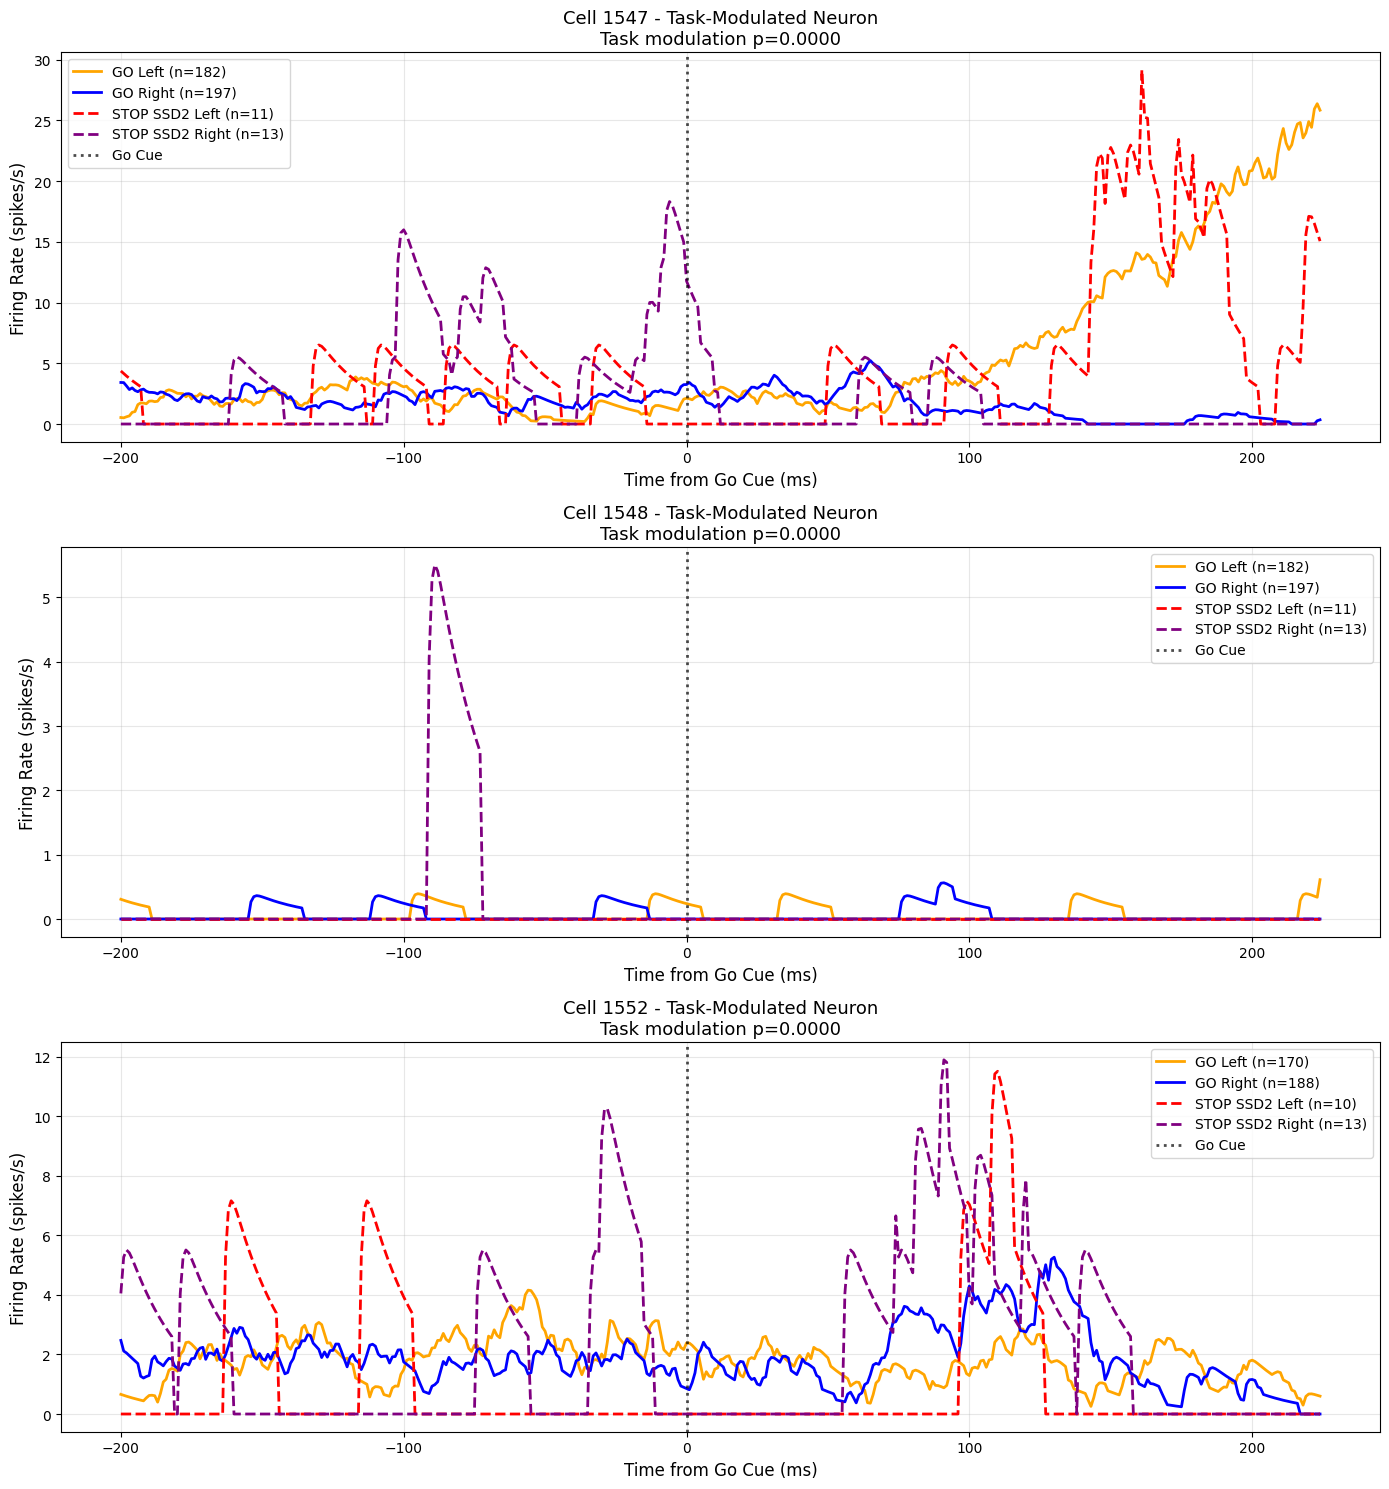


✓ Plotted 3 task-modulated neurons
  Showing GO and STOP SSD2 trials for both directions


In [24]:
# Visualize PSTHs for task-modulated neurons
print("\n" + "=" * 80)
print("VISUALIZING TASK-MODULATED NEURONS")
print("=" * 80)

if len(task_modulated_cells) > 0:
    # Select up to 3 example task-modulated cells
    n_examples = min(3, len(task_modulated_cells))
    example_cells = task_modulated_cells[:n_examples]
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 5*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        ax = axes[idx]
        
        # Plot GO left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=180,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='orange', label=f'GO Left (n={n_trials})')
        
        # Plot GO right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=0,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='blue', label=f'GO Right (n={n_trials})')
        
        # Plot STOP SSD2 left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=180,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='red', linestyle='--', label=f'STOP SSD{SSD_NUM} Left (n={n_trials})')
        
        # Plot STOP SSD2 right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=0,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='purple', linestyle='--', label=f'STOP SSD{SSD_NUM} Right (n={n_trials})')
        
        # Add vertical line at t=0 (go_cue)
        ax.axvline(0, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Go Cue')
        
        # Formatting
        ax.set_xlabel('Time from Go Cue (ms)', fontsize=12)
        ax.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
        ax.set_title(f'Cell {cell_id} - Task-Modulated Neuron\n' +
                    f'Task modulation p={cell_tuning["task_p"]:.4f}', fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plotted {n_examples} task-modulated neurons")
    print(f"  Showing GO and STOP SSD{SSD_NUM} trials for both directions")
else:
    print("\nNo task-modulated neurons found in this session.")


VISUALIZING STOP-SENSITIVE NEURONS

--- Test 3: Original Proposal ---
GO [100-300ms] from go_cue vs STOP [0-200ms] from stop_cue


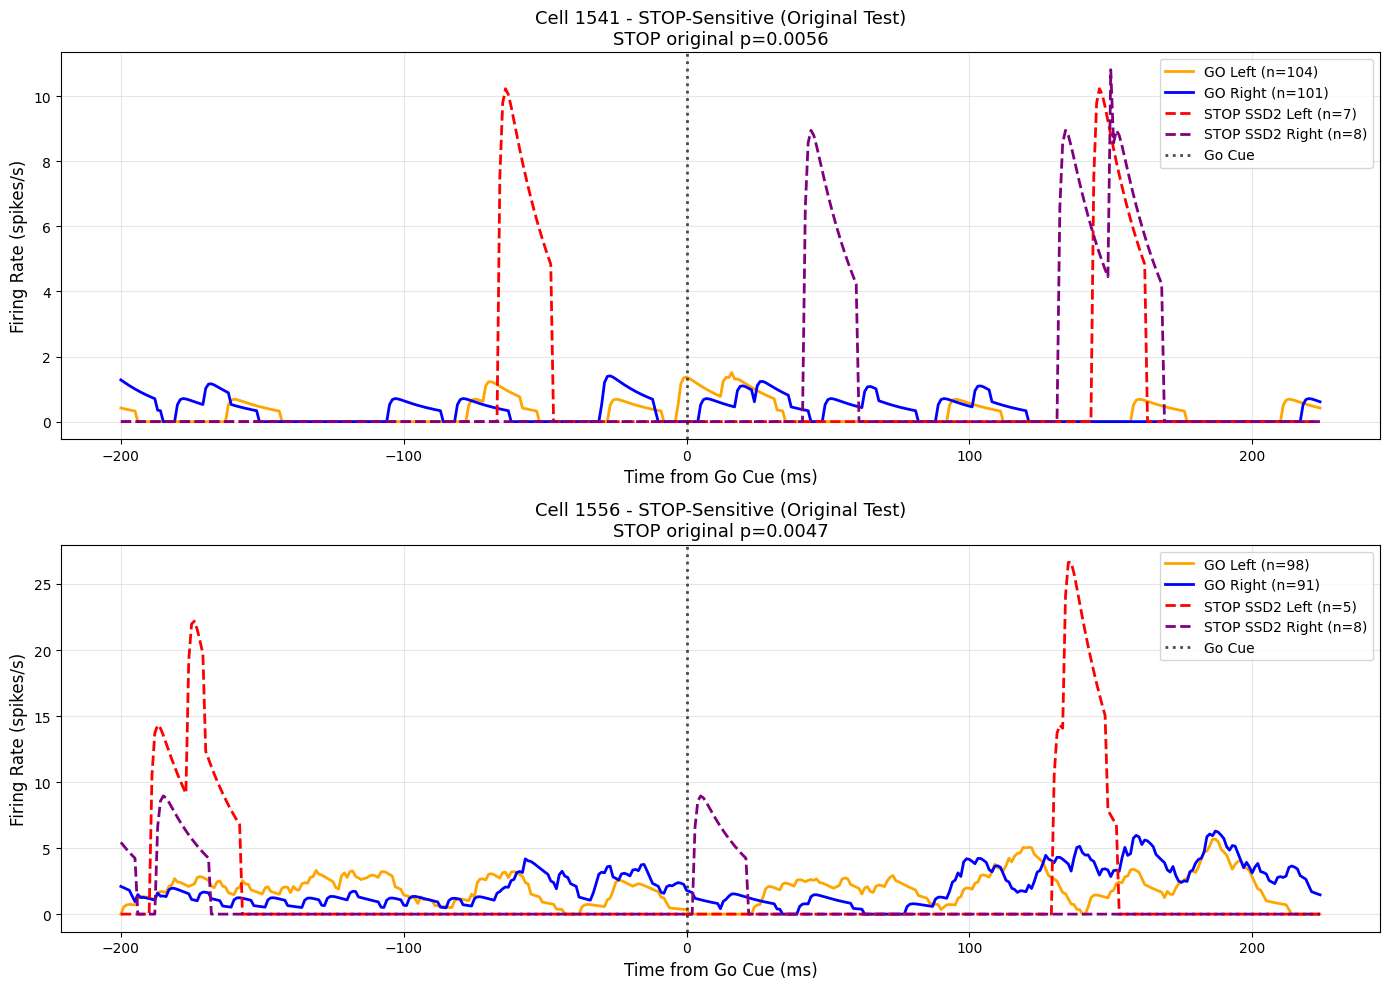

✓ Plotted 2 STOP-sensitive neurons (original test)

--- Test 4: Matched Proposal ---
GO [0-mean_SSD] from go_cue vs STOP [0-mean_SSD] from stop_cue


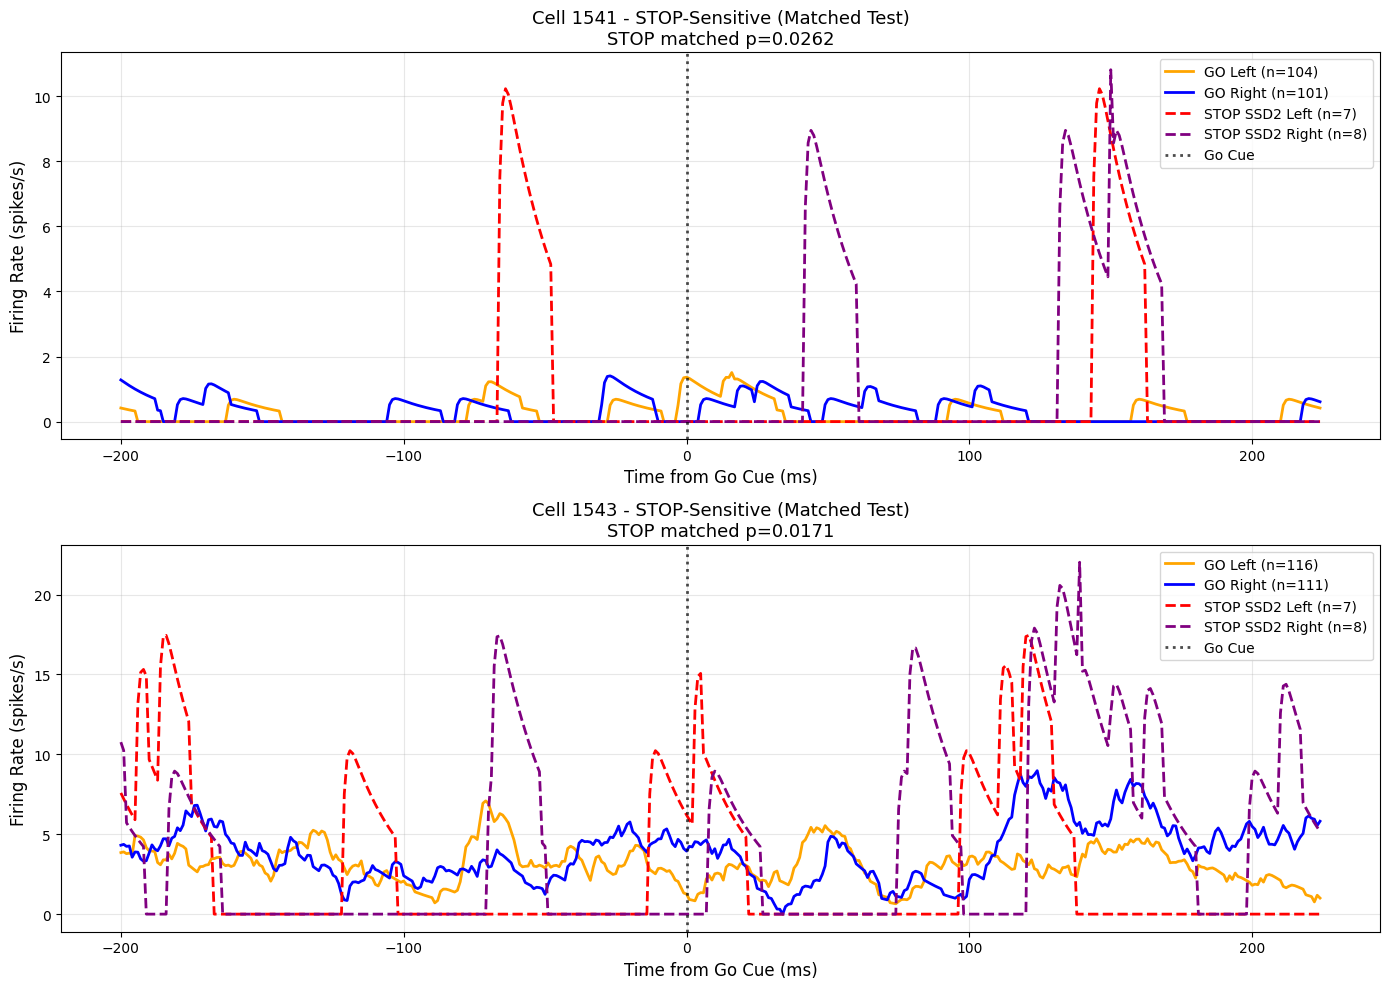

✓ Plotted 2 STOP-sensitive neurons (matched test)

Summary:
  Original test (GO [100-300ms] vs STOP [0-200ms]): 23 neurons
  Matched test (GO [0-mean_SSD] vs STOP [0-mean_SSD]): 24 neurons


In [25]:
# Visualize PSTHs for STOP-sensitive neurons
print("\n" + "=" * 80)
print("VISUALIZING STOP-SENSITIVE NEURONS")
print("=" * 80)

# Test 3: Original proposal (GO [100-300ms] vs STOP [0-200ms from stop_cue])
print("\n--- Test 3: Original Proposal ---")
print(f"GO [100-300ms] from go_cue vs STOP [0-200ms] from stop_cue")

if len(stop_sensitive_orig_cells) > 0:
    n_examples = min(2, len(stop_sensitive_orig_cells))
    example_cells = stop_sensitive_orig_cells[:n_examples]
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 5*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        ax = axes[idx]
        
        # Plot GO left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=180,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='orange', label=f'GO Left (n={n_trials})')
        
        # Plot GO right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=0,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='blue', label=f'GO Right (n={n_trials})')
        
        # Plot STOP SSD2 left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=180,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='red', linestyle='--', label=f'STOP SSD{SSD_NUM} Left (n={n_trials})')
        
        # Plot STOP SSD2 right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=0,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='purple', linestyle='--', label=f'STOP SSD{SSD_NUM} Right (n={n_trials})')
        
        # Add vertical line at t=0 (go_cue)
        ax.axvline(0, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Go Cue')
        
        # Formatting
        ax.set_xlabel('Time from Go Cue (ms)', fontsize=12)
        ax.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
        ax.set_title(f'Cell {cell_id} - STOP-Sensitive (Original Test)\n' +
                    f'STOP original p={cell_tuning["stop_original_p"]:.4f}', fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {n_examples} STOP-sensitive neurons (original test)")
else:
    print("No STOP-sensitive neurons found by original test")


# Test 4: Matched proposal (GO [0-mean_SSD] vs STOP [0-mean_SSD from stop_cue])
print("\n--- Test 4: Matched Proposal ---")
print(f"GO [0-mean_SSD] from go_cue vs STOP [0-mean_SSD] from stop_cue")

if len(stop_sensitive_match_cells) > 0:
    n_examples = min(2, len(stop_sensitive_match_cells))
    example_cells = stop_sensitive_match_cells[:n_examples]
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 5*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        ax = axes[idx]
        
        # Plot GO left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=180,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='orange', label=f'GO Left (n={n_trials})')
        
        # Plot GO right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=0,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='blue', label=f'GO Right (n={n_trials})')
        
        # Plot STOP SSD2 left
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=180,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='red', linestyle='--', label=f'STOP SSD{SSD_NUM} Left (n={n_trials})')
        
        # Plot STOP SSD2 right
        bin_centers, fr, n_trials = cell.calculate_psth(
            epok=[-200, 200],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='STOP',
            direction=0,
            ssd_number=SSD_NUM,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        if bin_centers is not None:
            ax.plot(bin_centers, fr, linewidth=2, color='purple', linestyle='--', label=f'STOP SSD{SSD_NUM} Right (n={n_trials})')
        
        # Add vertical line at t=0 (go_cue)
        ax.axvline(0, color='black', linestyle=':', alpha=0.7, linewidth=2, label='Go Cue')
        
        # Formatting
        ax.set_xlabel('Time from Go Cue (ms)', fontsize=12)
        ax.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
        ax.set_title(f'Cell {cell_id} - STOP-Sensitive (Matched Test)\n' +
                    f'STOP matched p={cell_tuning["stop_matched_p"]:.4f}', fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=10, loc='best')
    
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Plotted {n_examples} STOP-sensitive neurons (matched test)")
else:
    print("No STOP-sensitive neurons found by matched test")

print(f"\n{'='*80}")
print(f"Summary:")
print(f"  Original test (GO [100-300ms] vs STOP [0-200ms]): {len(stop_sensitive_orig_cells)} neurons")
print(f"  Matched test (GO [0-mean_SSD] vs STOP [0-mean_SSD]): {len(stop_sensitive_match_cells)} neurons")
print(f"{'='*80}")


VISUALIZING DIRECTION-TUNED NEURONS


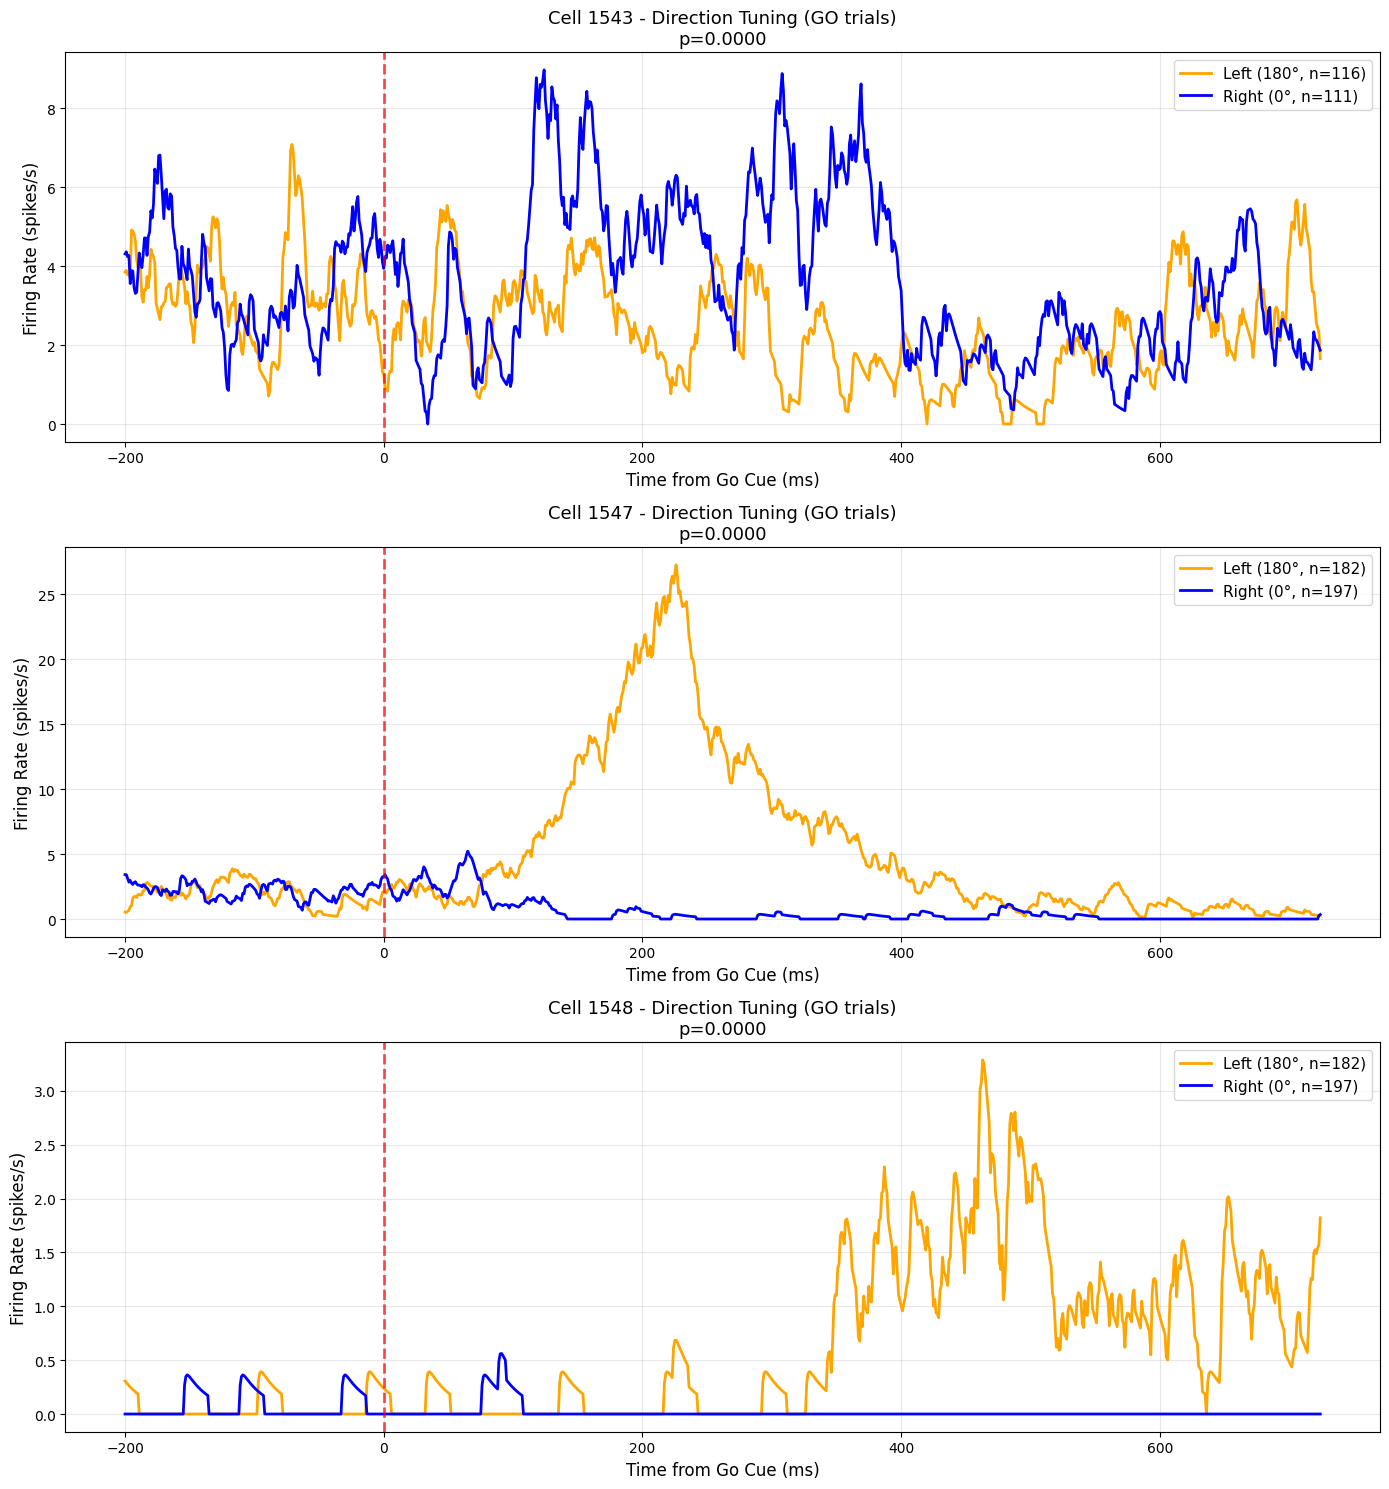


✓ Plotted 3 direction-tuned neurons


In [26]:
# Visualize PSTHs for direction-tuned neurons
print("\n" + "=" * 80)
print("VISUALIZING DIRECTION-TUNED NEURONS")
print("=" * 80)

if len(direction_tuned_cells) > 0:
    # Select up to 3 example direction-tuned cells
    n_examples = min(3, len(direction_tuned_cells))
    example_cells = direction_tuned_cells[:n_examples]
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 5*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        # Plot Left trials (180°)
        bin_centers_left, fr_left, n_trials_left = cell.calculate_psth(
            epok=[-200, 700],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=180,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        
        # Plot Right trials (0°)
        bin_centers_right, fr_right, n_trials_right = cell.calculate_psth(
            epok=[-200, 700],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=0,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        
        ax = axes[idx]
        
        # Plot both directions
        if bin_centers_left is not None:
            ax.plot(bin_centers_left, fr_left, linewidth=2, color='orange', 
                   label=f'Left (180°, n={n_trials_left})')
        if bin_centers_right is not None:
            ax.plot(bin_centers_right, fr_right, linewidth=2, color='blue', 
                   label=f'Right (0°, n={n_trials_right})')
        
        ax.axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax.set_xlabel('Time from Go Cue (ms)', fontsize=12)
        ax.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
        ax.set_title(f'Cell {cell_id} - Direction Tuning (GO trials)\n' + 
                    f'p={cell_tuning["direction_p"]:.4f}', fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plotted {n_examples} direction-tuned neurons")
else:
    print("\nNo direction-tuned neurons found in this session.")


VISUALIZING NON-TUNED NEURONS (for comparison)


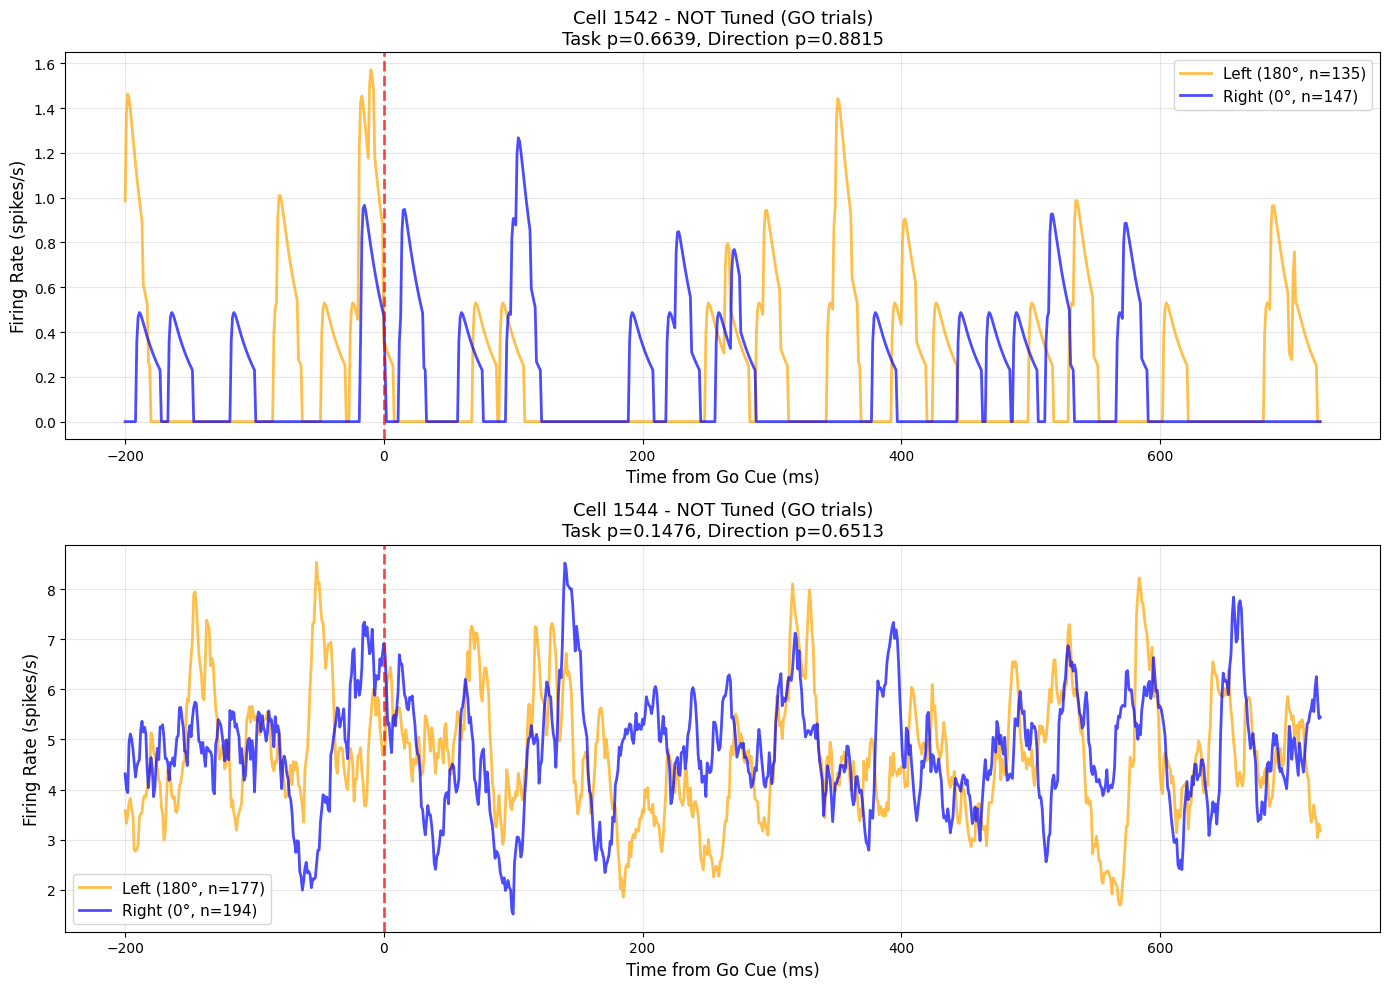


✓ Plotted 2 non-tuned neurons for comparison

Note: Non-tuned neurons show no significant difference between:
  - Baseline vs Task periods (task modulation)
  - Left vs Right directions (direction tuning)


In [27]:
# Visualize PSTHs for non-tuned neurons (as a contrast)
print("\n" + "=" * 80)
print("VISUALIZING NON-TUNED NEURONS (for comparison)")
print("=" * 80)

if len(not_tuned_cells) > 0:
    # Select up to 2 example non-tuned cells
    n_examples = min(2, len(not_tuned_cells))
    example_cells = not_tuned_cells[:n_examples]
    
    fig, axes = plt.subplots(n_examples, 1, figsize=(14, 5*n_examples))
    if n_examples == 1:
        axes = [axes]
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        # Plot Left trials (180°)
        bin_centers_left, fr_left, n_trials_left = cell.calculate_psth(
            epok=[-200, 700],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=180,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        
        # Plot Right trials (0°)
        bin_centers_right, fr_right, n_trials_right = cell.calculate_psth(
            epok=[-200, 700],
            bin_size=1,
            alignment_point='go_cue',
            trial_type='GO',
            direction=0,
            success_only=True,
            smooth=True,
            smooth_ker_size=25
        )
        
        ax = axes[idx]
        
        # Plot both directions
        if bin_centers_left is not None:
            ax.plot(bin_centers_left, fr_left, linewidth=2, color='orange', 
                   label=f'Left (180°, n={n_trials_left})', alpha=0.7)
        if bin_centers_right is not None:
            ax.plot(bin_centers_right, fr_right, linewidth=2, color='blue', 
                   label=f'Right (0°, n={n_trials_right})', alpha=0.7)
        
        ax.axvline(0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax.set_xlabel('Time from Go Cue (ms)', fontsize=12)
        ax.set_ylabel('Firing Rate (spikes/s)', fontsize=12)
        ax.set_title(f'Cell {cell_id} - NOT Tuned (GO trials)\n' + 
                    f'Task p={cell_tuning["task_p"]:.4f}, Direction p={cell_tuning["direction_p"]:.4f}', 
                    fontsize=13)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=11)
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n✓ Plotted {n_examples} non-tuned neurons for comparison")
    print("\nNote: Non-tuned neurons show no significant difference between:")
    print("  - Baseline vs Task periods (task modulation)")
    print("  - Left vs Right directions (direction tuning)")
else:
    print("\nNo non-tuned neurons found in this session (all neurons are tuned!).")

In [28]:
# Visualize PSTHs for STOP-sensitive neurons using plot_psth_by_type_direction
print("\n" + "=" * 80)
print("VISUALIZING STOP-SENSITIVE NEURONS")
print("=" * 80)

# Get cells that are sensitive to STOP (either test)
stop_sensitive_cells = list(set(stop_sensitive_orig_cells + stop_sensitive_match_cells))

if len(stop_sensitive_cells) > 0:
    # Select up to 2 example STOP-sensitive cells
    n_examples = min(2, len(stop_sensitive_cells))
    example_cells = stop_sensitive_cells[:n_examples]
    
    print(f"Plotting {n_examples} STOP-sensitive neurons showing GO and STOP trials by direction:")
    
    for idx, cell_id in enumerate(example_cells):
        cell = session.get_cell(cell_id)
        
        # Get tuning info
        cell_tuning = tuning_df[tuning_df['cell_id'] == cell_id].iloc[0]
        
        print(f"\nCell {cell_id}:")
        print(f"  STOP original p-value: {cell_tuning['stop_original_p']:.4f} ({'significant' if cell_tuning['stop_sensitive_original'] else 'not significant'})")
        print(f"  STOP matched p-value: {cell_tuning['stop_matched_p']:.4f} ({'significant' if cell_tuning['stop_sensitive_matched'] else 'not significant'})")
        
        # Use plot_psth_by_type_direction to show all conditions
        # Timeline that covers both tuning test windows
        cell.plot_psth_by_type_direction(
            epok=[-100, 400],
            bin_size=1,
            alignment_point='go_cue',
            separate_ssd=False,
            smooth=True,
            smooth_ker_size=25,
            delta=False,
            normalize_bins=False
        )
    
    print(f"\n✓ Plotted {n_examples} STOP-sensitive neurons")
    print(f"\nNote: Plot shows GO left, GO right, STOP left, and STOP right trials")
    print(f"  - GO trials aligned to go_cue")
    print(f"  - STOP trials aligned to go_cue (stop_cue occurs at ~mean_SSD ms)")
    print(f"\nTotal STOP-sensitive neurons found:")
    print(f"  Original test (GO [100-300ms] vs STOP [0-200ms from stop_cue]): {len(stop_sensitive_orig_cells)}")
    print(f"  Matched test (GO [0-mean_SSD] vs STOP [0-mean_SSD from stop_cue]): {len(stop_sensitive_match_cells)}")
    print(f"  Either test: {len(stop_sensitive_cells)}")
else:
    print("\nNo STOP-sensitive neurons found in this session.")


VISUALIZING STOP-SENSITIVE NEURONS
Plotting 2 STOP-sensitive neurons showing GO and STOP trials by direction:

Cell 1541:
  STOP original p-value: 0.0056 (significant)
  STOP matched p-value: 0.0262 (significant)

Cell 1670:
  STOP original p-value: 0.0000 (significant)
  STOP matched p-value: 0.0000 (significant)



✓ Plotted 2 STOP-sensitive neurons

Note: Plot shows GO left, GO right, STOP left, and STOP right trials
  - GO trials aligned to go_cue
  - STOP trials aligned to go_cue (stop_cue occurs at ~mean_SSD ms)

Total STOP-sensitive neurons found:
  Original test (GO [100-300ms] vs STOP [0-200ms from stop_cue]): 23
  Matched test (GO [0-mean_SSD] vs STOP [0-mean_SSD from stop_cue]): 24
  Either test: 39



TUNING P-VALUE DISTRIBUTIONS


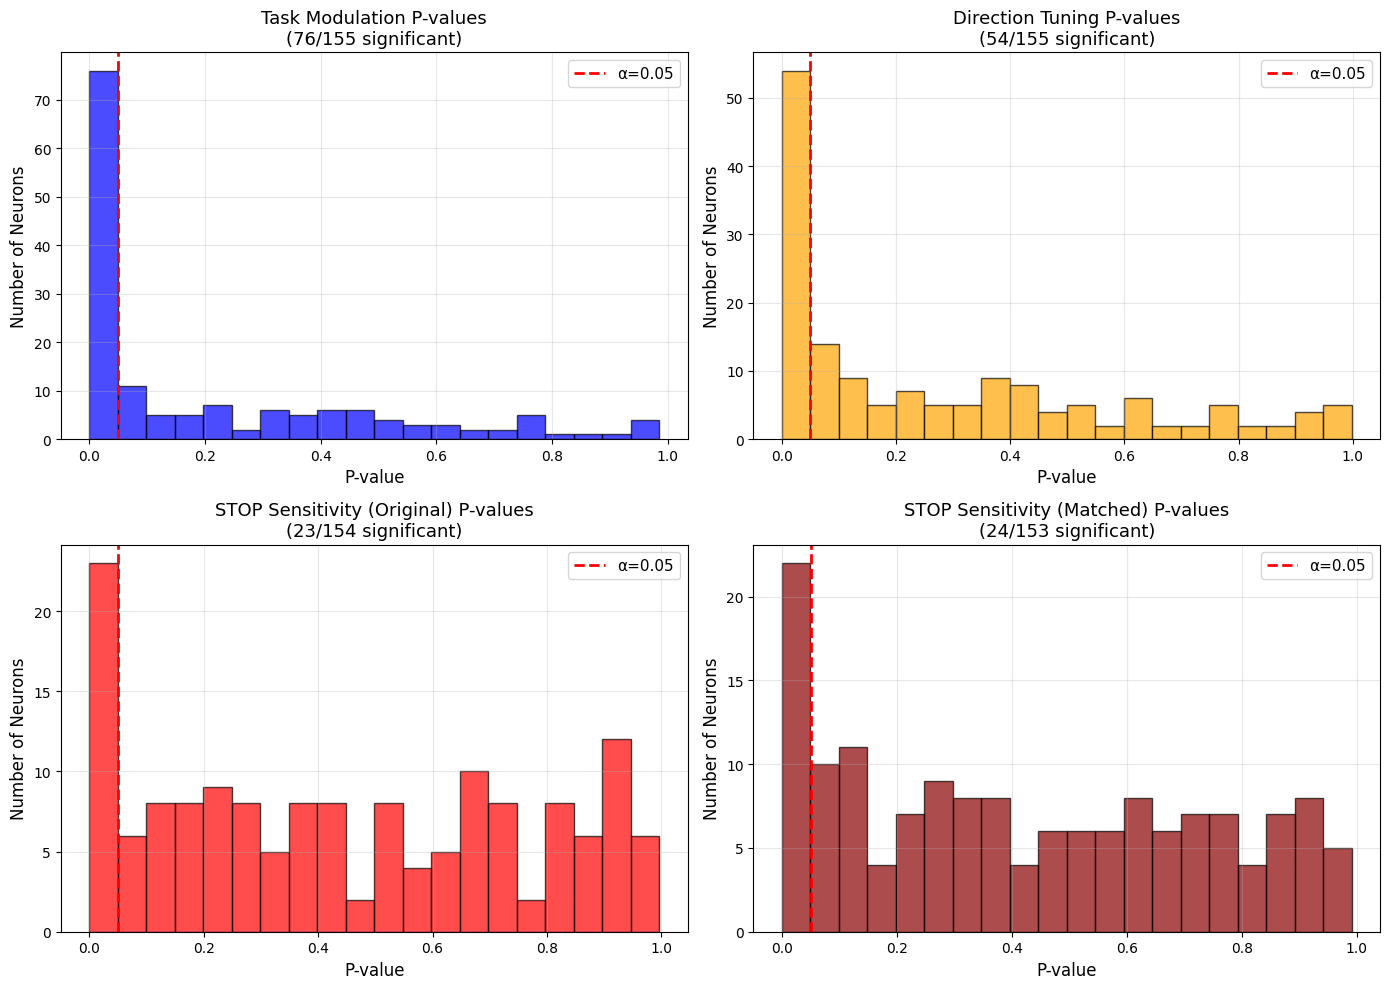


✓ P-value distributions look reasonable
  - Values < 0.05 indicate significant tuning
  - Distribution should be relatively uniform if testing is working correctly

Note: STOP sensitivity tests may have fewer data points due to limited STOP trials


In [29]:
# Plot distribution of p-values to verify tuning analysis
print("\n" + "=" * 80)
print("TUNING P-VALUE DISTRIBUTIONS")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Task modulation p-values
valid_task_p = tuning_df['task_p'].dropna()
axes[0, 0].hist(valid_task_p, bins=20, edgecolor='black', alpha=0.7, color='blue')
axes[0, 0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
axes[0, 0].set_xlabel('P-value', fontsize=12)
axes[0, 0].set_ylabel('Number of Neurons', fontsize=12)
axes[0, 0].set_title(f'Task Modulation P-values\n({n_task_modulated}/{len(valid_task_p)} significant)', fontsize=13)
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(alpha=0.3)

# Direction tuning p-values
valid_dir_p = tuning_df['direction_p'].dropna()
axes[0, 1].hist(valid_dir_p, bins=20, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
axes[0, 1].set_xlabel('P-value', fontsize=12)
axes[0, 1].set_ylabel('Number of Neurons', fontsize=12)
axes[0, 1].set_title(f'Direction Tuning P-values\n({n_direction_tuned}/{len(valid_dir_p)} significant)', fontsize=13)
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(alpha=0.3)

# STOP sensitivity (original) p-values
valid_stop_orig_p = tuning_df['stop_original_p'].dropna()
axes[1, 0].hist(valid_stop_orig_p, bins=20, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
axes[1, 0].set_xlabel('P-value', fontsize=12)
axes[1, 0].set_ylabel('Number of Neurons', fontsize=12)
axes[1, 0].set_title(f'STOP Sensitivity (Original) P-values\n({n_stop_orig}/{len(valid_stop_orig_p)} significant)', fontsize=13)
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(alpha=0.3)

# STOP sensitivity (matched) p-values
valid_stop_match_p = tuning_df['stop_matched_p'].dropna()
axes[1, 1].hist(valid_stop_match_p, bins=20, edgecolor='black', alpha=0.7, color='darkred')
axes[1, 1].axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
axes[1, 1].set_xlabel('P-value', fontsize=12)
axes[1, 1].set_ylabel('Number of Neurons', fontsize=12)
axes[1, 1].set_title(f'STOP Sensitivity (Matched) P-values\n({n_stop_match}/{len(valid_stop_match_p)} significant)', fontsize=13)
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ P-value distributions look reasonable")
print(f"  - Values < 0.05 indicate significant tuning")
print(f"  - Distribution should be relatively uniform if testing is working correctly")
print(f"\nNote: STOP sensitivity tests may have fewer data points due to limited STOP trials")


TUNING P-VALUE DISTRIBUTIONS


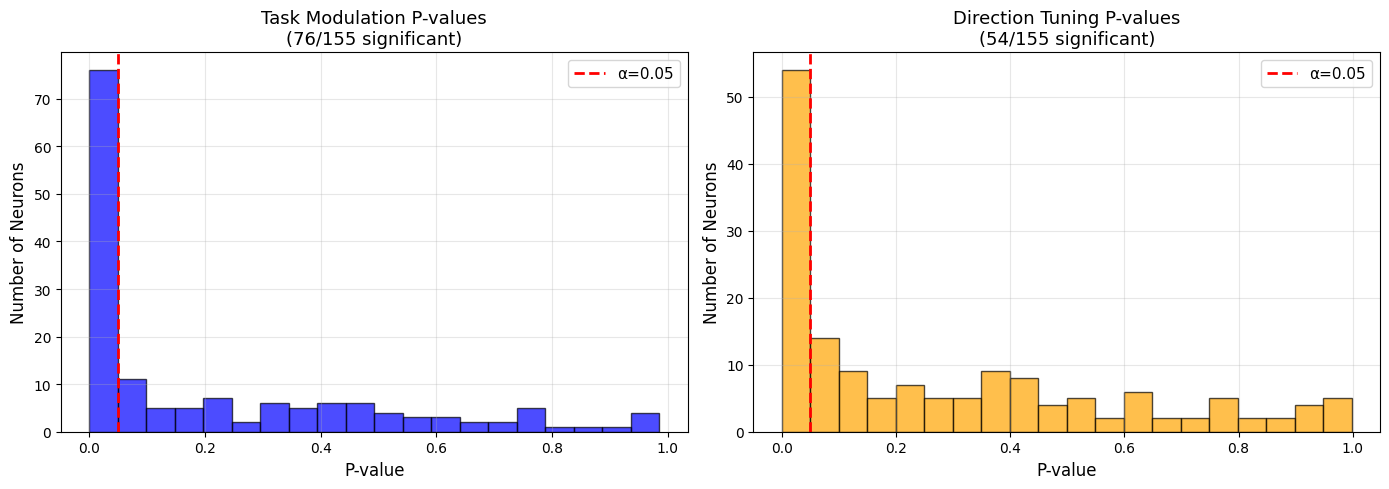


✓ P-value distributions look reasonable
  - Values < 0.05 indicate significant tuning
  - Distribution should be relatively uniform if testing is working correctly


In [30]:
# Plot distribution of p-values to verify tuning analysis
print("\n" + "=" * 80)
print("TUNING P-VALUE DISTRIBUTIONS")
print("=" * 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Task modulation p-values
valid_task_p = tuning_df['task_p'].dropna()
ax1.hist(valid_task_p, bins=20, edgecolor='black', alpha=0.7, color='blue')
ax1.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
ax1.set_xlabel('P-value', fontsize=12)
ax1.set_ylabel('Number of Neurons', fontsize=12)
ax1.set_title(f'Task Modulation P-values\n({n_task_modulated}/{len(valid_task_p)} significant)', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Direction tuning p-values
valid_dir_p = tuning_df['direction_p'].dropna()
ax2.hist(valid_dir_p, bins=20, edgecolor='black', alpha=0.7, color='orange')
ax2.axvline(0.05, color='red', linestyle='--', linewidth=2, label='α=0.05')
ax2.set_xlabel('P-value', fontsize=12)
ax2.set_ylabel('Number of Neurons', fontsize=12)
ax2.set_title(f'Direction Tuning P-values\n({n_direction_tuned}/{len(valid_dir_p)} significant)', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✓ P-value distributions look reasonable")
print(f"  - Values < 0.05 indicate significant tuning")
print(f"  - Distribution should be relatively uniform if testing is working correctly")